# Import packages

[1 Preprocess](#Preprocess)

[2 Panel Regression Analysis](#Panel-Regression-Analysis)

----[2.1 Distribution Histogram](#Distribution-Histogram)

----[2.2 Fixed Effect Panel Regression](#Fixed-Effect-Panel-Regression)

----[2.3 Fixed Effect Panel Regression(after filtered)](#Fixed-Effect-Panel-Regression-2)

----[3 Time Series Analysis Result](#Time-Series-Analysis-Result)

[4 NMR Map](#NMR-Map)

[5 Disaster Map (Only for display, used maps are created by ArcGIS)](#Disaster-Map)

[6 XGBoost Results](#XGBoost)

----[6.1 Summary Plot of XGBoost](#Summary-Plot-of-XGBoost)

----[6.2 Dependence Plot of XGBoost](#Dependence-Plot-of-XGBoost)

----[6.3 Summary Plot of XGBoost for Disaster Variables Only](#Summary-Plot-of-XGBoost-for-Disaster-Variables-Only)

[7 Hierarchical Regression](#Hierarchical-Regression)

----[7.1 Hierarchical Regression of All Variables](#Hierarchical-Regression-of-All-Variables)

----[7.2 Hierarchical Regression of Flood](#Hierarchical-Regression-of-Flood)

----[7.3 Hierarchical Regression of Hurricane](#Hierarchical-Regression-of-Hurricane)

----[7.4 Hierarchical Regression of Tornado](#Hierarchical-Regression-of-Tornado)

----[7.5 Hierarchical Regression of Wildfire](#Hierarchical-Regression-of-Wildfire)

In [463]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import contextily as cx
import xgboost as xgb
import shap
import statsmodels.api as sm
import matplotlib.colors as mcolors
from scipy.stats import pearsonr, spearmanr
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import RobustScaler
from linearmodels.panel import PanelOLS,compare
from linearmodels import RandomEffects
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Preprocess

### Add SHELDUS, Census, PEP, SVI, and NRI (FEMA Disaster Index) data

In [366]:
data_path = r"F:/LongMig2025/data/"
SHELDUS = pd.read_csv(data_path + "SHELDUS/ORIGINAL.csv")
state   = gpd.read_file(data_path + "Census/usstate/cb_2018_us_state_500k.shp").to_crs('ESRI:102003')
county  = gpd.read_file(data_path + "Census/maincounty/us_conu_county.shp").to_crs('ESRI:102003')
df_pep_2010 = pd.read_csv(data_path + "PEP/co-est2010-alldata.csv", encoding='latin-1')
df_pep_2020 = pd.read_csv(data_path + "PEP/co-est2020-alldata.csv", encoding='latin-1')
SVI_10  = pd.read_csv(data_path + "SVI/SVI_2010_US_county.csv")
SVI_10['FIPS'] = SVI_10['FIPS'].astype("str").str.rjust(5,"0")
state   = state[~state["NAME"].isin(["Alaska","Hawaii","Puerto Rico",
                                   "American Samoa","United States Virgin Islands",
                                   "Guam","Commonwealth of the Northern Mariana Islands"])]
NRI     = pd.read_csv(data_path + "NRI/NRI_Table_Counties/NRI_Table_Counties.csv")

### Add Employment data, Population Density data, JanuaryTemp, JulyTemp, and House Price data

In [367]:
# Employment = pd.read_csv(data_path + "Unemployment.csv")
PopDensity = pd.read_csv(data_path + "POPDen/2010/PopDensity2010.csv")
# HPI        = pd.read_csv(data_path + "HPI/hpi_master.csv")
# house_price= pd.read_csv(data_path + "Zillow/County_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
MedianHouseValue2000 = pd.read_csv(data_path + "MedianHouseValue/DECENNIALSF32000.H076-Data.csv")
MedianHouseValue2020 = pd.read_csv(data_path + "MedianHouseValue/ACSDT5Y2020.B25077-Data.csv")
# GDP        = pd.read_csv(data_path + "GDP/CAGDP1_ALL_AREAS_2001_2023.csv",  encoding='latin1')
TJan    = pd.read_csv(data_path + "PRISM/Tmean_Jan_All.csv")
TJuly   = pd.read_csv(data_path + "PRISM/Tmean_July_All.csv")
HAI     = pd.read_csv(data_path + "LAI/HAI_W.csv")
# LAI     = pd.read_csv(data_path + "LAI/LAI.csv")

### Process of PEP data

In [368]:
df_pep_2010["state"] = df_pep_2010["STATE"].astype('int64').astype('str').str.rjust(2, "0")
df_pep_2010["county"] = df_pep_2010["COUNTY"].astype('int64').astype('str').str.rjust(3, "0")
df_pep_2010["FIPS"] = df_pep_2010["state"] + df_pep_2010["county"]

df_pep_2020["state"] = df_pep_2020["STATE"].astype('int64').astype('str').str.rjust(2, "0")
df_pep_2020["county"] = df_pep_2020["COUNTY"].astype('int64').astype('str').str.rjust(3, "0")
df_pep_2020["FIPS"] = df_pep_2020["state"] + df_pep_2020["county"]

In [369]:
df_pep_0120 = pd.merge(df_pep_2010,df_pep_2020,on="FIPS")

### Process of Pop Density

In [370]:
PopDensity_CONUS = PopDensity[~(PopDensity["STATE"] == 2)]
PopDensity_CONUS = PopDensity_CONUS[~(PopDensity_CONUS["STATE"] == 15)]
PopDensity_CONUS["FIPS"] = PopDensity_CONUS['GEOID10'].astype(str).str.rjust(5,"0")
PopDensity_CONUS_sel = PopDensity_CONUS[["FIPS","POPDENS10"]]

### Process of House Price

In [371]:
# house_price['StateCodeFIPS'] = house_price['StateCodeFIPS'].astype(str).str.zfill(2)
# house_price['MunicipalCodeFIPS'] = house_price['MunicipalCodeFIPS'].astype(str).str.zfill(3)
# house_price['FIPS'] = house_price['StateCodeFIPS'] + house_price['MunicipalCodeFIPS']

# monthly_columns = [col for col in house_price.columns if '-' in col and len(col.split('-')[0]) == 4]

# monthly_data = house_price[['FIPS'] + monthly_columns].copy()
# monthly_data = monthly_data.melt(id_vars=['FIPS'], var_name='date', value_name='price')
# monthly_data['date'] = pd.to_datetime(monthly_data['date'])
# monthly_data['year'] = monthly_data['date'].dt.year

# annual_prices = monthly_data.groupby(['FIPS', 'year'])['price'].mean().reset_index()

# annual_prices_pivot = annual_prices.pivot(index='FIPS', columns='year', values='price').reset_index()

# def calculate_ratio(row):
#     available_years = row[annual_price_columns].dropna()
#     if len(available_years) > 1:
#         first_year = available_years.index[0]
#         last_year = available_years.index[-1]
#         return ((available_years[last_year] - available_years[first_year]) / available_years[first_year]) * 100
#     return None 

# def calculate_average(row):
#     available_years = row[annual_price_columns].dropna()
#     if len(available_years) > 0:
#         return available_years.mean()
#     return None  # Return None if no data is available

# annual_price_columns = [col for col in annual_prices_pivot.columns if isinstance(col, int)]

# annual_prices_pivot['ratio_HP'] = annual_prices_pivot.apply(calculate_ratio, axis=1)
# annual_prices_pivot['average_HP'] = annual_prices_pivot.apply(calculate_average, axis=1)

# annual_prices_pivot_cleaned = annual_prices_pivot.dropna(subset=annual_price_columns, how='all')

# non_conus_fips_prefixes = ['02', '15', '60', '66', '69', '72', '78']  # Alaska, Hawaii, and island territories

# annual_prices_pivot_cleaned['FIPS'] = annual_prices_pivot_cleaned['FIPS'].astype(str)
# conus_annual_prices = annual_prices_pivot_cleaned[
#     ~annual_prices_pivot_cleaned['FIPS'].str[:2].isin(non_conus_fips_prefixes)
# ]

## Process of Median House Value

In [372]:
MedianHouseValue2000["FIPS"] = MedianHouseValue2000["GEO_ID"].str[-5:]
MedianHouseValue2000["FIPS"]  = MedianHouseValue2000["FIPS"].astype(str).str.rjust(5,"0")
MedianHouseValue2000["H076001"] = pd.to_numeric(MedianHouseValue2000["H076001"], errors='coerce')
# CPI for 2000 = 172.2, CPI for 2020 = 258.811
cpi_2000 = 172.2
cpi_2020 = 258.811
adjustment_factor = cpi_2020 / cpi_2000
MedianHouseValue2000["MedianHouseValue2000(adjusted)"] = (
    MedianHouseValue2000["H076001"] * adjustment_factor
).round(0)
MedianHouseValue2000 = MedianHouseValue2000[["FIPS","MedianHouseValue2000(adjusted)"]]

In [373]:
MedianHouseValue2020["FIPS"] = MedianHouseValue2020["GEO_ID"].str[-5:]
MedianHouseValue2020["FIPS"]  = MedianHouseValue2020["FIPS"].astype(str).str.rjust(5,"0")
MedianHouseValue2020["MedianHouseValue2020"] = MedianHouseValue2020["B25077_001E"]
MedianHouseValue2020["MedianHouseValue2020"] = pd.to_numeric(MedianHouseValue2020["MedianHouseValue2020"], errors='coerce')
MedianHouseValue2020 = MedianHouseValue2020[["FIPS","MedianHouseValue2020"]]

In [374]:
MedianHouseValue = pd.merge(MedianHouseValue2000,MedianHouseValue2020,on="FIPS")
MedianHouseValue["ratiochange"] = (MedianHouseValue["MedianHouseValue2020"]-MedianHouseValue["MedianHouseValue2000(adjusted)"])/MedianHouseValue["MedianHouseValue2000(adjusted)"]*100

In [375]:
county_used = county[["FIPS","geometry"]]
gdf_MedianHouseValue = pd.merge(county_used,MedianHouseValue,on="FIPS",how="inner")
gdf_MedianHouseValue = gpd.GeoDataFrame(gdf_MedianHouseValue,geometry="geometry")

<Axes: >

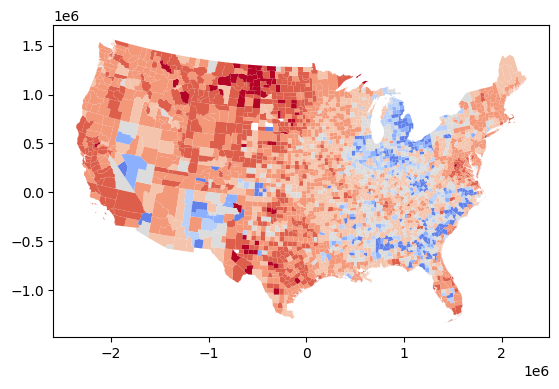

In [376]:
gdf_MedianHouseValue.plot("ratiochange",cmap="coolwarm",
#                           scheme='quantiles', 
                          scheme='userdefined',
                          classification_kwds={'bins':[-50,-10,-5,0,10,25,50,100,500]})

In [377]:
MedianHouseValue.head()

,FIPS,MedianHouseValue2000(adjusted),MedianHouseValue2020,ratiochange
0,01001,142481.0,161200.0,13.137892
1,01003,184114.0,211600.0,14.928794
2,01005,103104.0,86500.0,-16.104128
3,01007,112121.0,96400.0,-14.021459
4,01009,130458.0,135300.0,3.711539


### Process of Amenity data

In [378]:
TJan["FIPS"]  = TJan["FIPS"].astype(str).str.rjust(5,"0")
TJuly["FIPS"] = TJuly["FIPS"].astype(str).str.rjust(5,"0")
TJan_sel  = TJan[["FIPS","MEAN"]].rename(columns={"MEAN":"TJAN"})
TJuly_sel = TJuly[["FIPS","MEAN"]].rename(columns={"MEAN":"TJULY"})
T_sel = pd.merge(TJan_sel,TJuly_sel,on="FIPS")

### Process of Location Affordability Index (LAI)

In [379]:
HAI["FIPS"]  = HAI["FIPS"].astype(str).str.rjust(5,"0")
HAI = HAI.rename(columns={
    "Weight_HAI":"W_HT_HAI"
#     "MEAN_hh_type1_h":"W_HT_LAI"
})
HAI = HAI[["FIPS","W_HT_HAI"]]
non_conus_fips_prefixes = ['02', '15', '60', '66', '69', '72', '78']  # Alaska, Hawaii, and island territories
HAI = HAI[
    ~HAI['FIPS'].str[:2].isin(non_conus_fips_prefixes)
]

### Process of SHELDUS

In [380]:
SHELDUS['County FIPS'] = SHELDUS['County FIPS'].str.replace("'", "")
SHELDUS_0020 = SHELDUS[(SHELDUS["Year"]<2021) & (SHELDUS["Year"]>2000)]
SHELDUS_0020 = SHELDUS_0020[~((SHELDUS_0020['Year'] == 2000) & (SHELDUS_0020['Month'] <= 6))]
SHELDUS_0020 = SHELDUS_0020[~((SHELDUS_0020['Year'] == 2020) & (SHELDUS_0020['Month'] >= 7))]
SHELDUS_0020["StateID"] = SHELDUS_0020["County FIPS"].astype(str).str[:2]
SHELDUS_0020 = SHELDUS_0020[~SHELDUS_0020["StateID"].isin(non_conus_fips_prefixes)]
SHELDUS_0020_dis = SHELDUS_0020.groupby(["Hazard"]).agg({"PropertyDmg(ADJ 2020)":"sum","Fatalities":"sum","Injuries":"sum"}).reset_index()
SHELDUS_0020_dis.sort_values(by="PropertyDmg(ADJ 2020)",ascending=False)

,Hazard,PropertyDmg(ADJ 2020),Fatalities,Injuries
4,Flooding,2.056574e+11,1648.020,1387.000
8,Hurricane/Tropical Storm,1.759030e+11,1215.980,1300.010
12,Tornado,3.784049e+10,1504.000,19077.000
15,Wildfire,3.218132e+10,296.000,1619.960
6,Hail,2.999533e+10,3.000,620.000
16,Wind,1.825596e+10,973.315,3993.930
17,Winter Weather,1.136860e+10,648.995,2833.035
11,Severe Storm/Thunder Storm,5.431994e+09,303.500,2387.000
3,Earthquake,4.256910e+09,7.990,223.000
9,Landslide,3.151915e+09,183.960,300.010


In [381]:
SHELDUS_0020_sel = SHELDUS_0020[SHELDUS_0020["Hazard"].isin(['Flooding','Hurricane/Tropical Storm','Wildfire','Tornado'])].reset_index(drop=True)
SHELDUS_0020_sel_use = SHELDUS_0020_sel[['County FIPS', 'Hazard', 'Year',"Month",'PropertyDmg(ADJ 2020)','Fatalities','Injuries']]

def calculate_period(row):
    year = row['Year']
    month = row['Month']
    # If month is from July to December, the period is the current year
    if month >= 7:
        return year +1
    # If month is from January to June, the period is the previous year
    else:
        return year

# Apply the function to the dataframe
SHELDUS_0020_sel_use['Period'] = SHELDUS_0020_sel_use.apply(calculate_period, axis=1)
SHELDUS_0020_sel_use["Count"]  = 1
SHELDUS_0020_sel_use_group = SHELDUS_0020_sel_use.groupby(["County FIPS","Hazard","Period"]).agg({"PropertyDmg(ADJ 2020)":"sum",
                                                                                                 'Fatalities':"sum",
                                                                                                  'Injuries':"sum",
                                                                                                  "Count":"sum"}).reset_index()

C:\Users\xiang11\AppData\Local\Temp\ipykernel_24316\2092878197.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SHELDUS_0020_sel_use['Period'] = SHELDUS_0020_sel_use.apply(calculate_period, axis=1)
C:\Users\xiang11\AppData\Local\Temp\ipykernel_24316\2092878197.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SHELDUS_0020_sel_use["Count"]  = 1


# Panel Regression Analysis

### Create the panel dataframe

In [382]:
correct_pop_columns = ["FIPS","POPESTIMATE2000","POPESTIMATE2001","POPESTIMATE2002","POPESTIMATE2003","POPESTIMATE2004",
                       "POPESTIMATE2005","POPESTIMATE2006","POPESTIMATE2007","POPESTIMATE2008","POPESTIMATE2009",
                       "POPESTIMATE2010_x","POPESTIMATE2011","POPESTIMATE2012","POPESTIMATE2013","POPESTIMATE2014",
                       "POPESTIMATE2015","POPESTIMATE2016","POPESTIMATE2017","POPESTIMATE2018","POPESTIMATE2019","POPESTIMATE2020"]
correct_pop_columns_rev = ["FIPS","POP2000","POP2001","POP2002","POP2003","POP2004",
                       "POP2005","POP2006","POP2007","POP2008","POP2009",
                       "POP2010","POP2011","POP2012","POP2013","POP2014",
                       "POP2015","POP2016","POP2017","POP2018","POP2019","POP2020"]
df_pep_0120_pop_use = df_pep_0120[correct_pop_columns]
df_pep_0120_pop_use.columns = correct_pop_columns_rev

In [383]:
years = range(2000, 2021)
year_cols = [f'POP{year}' for year in years]
df2_long = pd.melt(df_pep_0120_pop_use, id_vars=['FIPS'], value_vars=year_cols, var_name='Year', value_name='Population')
df2_long['Year'] = df2_long['Year'].str.extract('(\d+)').astype(int)  # Convert Year to integer

# Merge the dataframes
SHELDUS_0020_sel_use_group['County FIPS'] = SHELDUS_0020_sel_use_group['County FIPS'].astype(str)  # Ensure FIPS codes are strings if they have leading zeros
SHELDUS_0020_sel_use_group['Year'] = SHELDUS_0020_sel_use_group['Period'].astype(int)  # Ensure Year is integer
# merged_df = pd.merge(SHELDUS_0020_sel_use_group, df2_long, left_on=['County FIPS', 'Year'], right_on=['FIPS', 'Year'], how='left')

# Result
# merged_df["PropertyDmgPerCapita"] = merged_df["PropertyDmg(ADJ 2020)"] / merged_df["Population"]

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\xiang11\AppData\Local\Temp\ipykernel_24316\2987025524.py:4: SyntaxWarning: invalid escape sequence '\d'
  df2_long['Year'] = df2_long['Year'].str.extract('(\d+)').astype(int)  # Convert Year to integer


In [384]:
SHELDUS_0020_sel_use_group

,County FIPS,Hazard,Period,PropertyDmg(ADJ 2020),Fatalities,Injuries,Count,Year
0,01001,Flooding,2001,54762.44,0.0,0.0,1,2001
1,01001,Flooding,2003,71228.16,0.0,0.0,1,2003
2,01001,Flooding,2004,11396.51,0.0,0.0,1,2004
3,01001,Flooding,2005,36601.51,0.0,0.0,3,2005
4,01001,Flooding,2009,708639.49,0.0,0.0,2,2009
...,...,...,...,...,...,...,...,...
31313,56045,Flooding,2013,33837.95,0.0,0.0,2,2013
31314,56045,Flooding,2014,123770.31,0.0,0.0,2,2014
31315,56045,Flooding,2015,33177.32,0.0,0.0,1,2015
31316,56045,Flooding,2020,35400.46,0.0,0.0,2,2020


In [385]:
disaster_list = ['Flooding', 'Hurricane/Tropical Storm', 'Tornado', 'Wildfire']
df_disaster_year = list()
for each in disaster_list:
    df_temp_used = SHELDUS_0020_sel_use_group[SHELDUS_0020_sel_use_group["Hazard"]==each]
    df_temp_used_merge = pd.merge(df2_long,df_temp_used,left_on=["FIPS","Year"],right_on=["County FIPS","Year"],how = "outer")
    df_temp_used_merge = df_temp_used_merge[["FIPS","Year","Population","PropertyDmg(ADJ 2020)","Fatalities","Injuries","Count"]]
    df_temp_used_merge["PropertyDmgPerCapita"] = df_temp_used_merge["PropertyDmg(ADJ 2020)"]/df_temp_used_merge["Population"]
    df_temp_used_merge["Existance"] = np.where(
    df_temp_used_merge['Count'] > 0,
    1,
    0
)
    df_temp_used_merge = df_temp_used_merge.fillna(0)
    df_disaster_year.append(df_temp_used_merge)

### Next step is to create the yearly panel data for each disaster

In [386]:
df_flood_year = df_disaster_year[0]
df_hurricane_year = df_disaster_year[1]
df_tornado_year = df_disaster_year[2]
df_wildfire_year = df_disaster_year[3]

In [387]:
def calculate_disaster_existence_percentages(df, fips_col="FIPS", year_col="Year", exist_col="Existance"):
    df_sorted = df.sort_values(by=[fips_col, year_col]).copy()
    df_sorted["Existance_lag1"] = df_sorted.groupby(fips_col)[exist_col].shift(1)

    both = ((df_sorted[exist_col] == 1) & (df_sorted["Existance_lag1"] == 1)).sum()
    either = ((df_sorted[exist_col] == 1) | (df_sorted["Existance_lag1"] == 1)).sum()
    neither = ((df_sorted[exist_col] == 0) & (df_sorted["Existance_lag1"] == 0)).sum()
    total = len(df_sorted)

    return {
        "both_current_and_last_year": round(100 * both / total, 2),
        "either_current_or_last_year": round(100 * either / total, 2),
        "neither_current_nor_last_year": round(100 * neither / total, 2)
    }

In [388]:
calculate_disaster_existence_percentages(df_flood_year)

{'both_current_and_last_year': 12.44,
 'either_current_or_last_year': 40.66,
 'neither_current_nor_last_year': 54.58}

In [389]:
calculate_disaster_existence_percentages(df_hurricane_year)

{'both_current_and_last_year': 0.54,
 'either_current_or_last_year': 5.49,
 'neither_current_nor_last_year': 89.75}

In [390]:
calculate_disaster_existence_percentages(df_tornado_year)

{'both_current_and_last_year': 3.72,
 'either_current_or_last_year': 24.3,
 'neither_current_nor_last_year': 70.93}

In [391]:
calculate_disaster_existence_percentages(df_wildfire_year)

{'both_current_and_last_year': 0.57,
 'either_current_or_last_year': 3.79,
 'neither_current_nor_last_year': 91.45}

In [392]:
correct_netmig_columns = []
for year in range(2001, 2021):
    column_name_x = f'RNETMIG{year}_x'
    column_name_y = f'RNETMIG{year}_y'
    column_name = f'RNETMIG{year}'
    if column_name in df_pep_0120.columns:
        correct_netmig_columns.append(column_name)
    elif column_name_x in df_pep_0120.columns:
        correct_netmig_columns.append(column_name_x)
    elif column_name_y in df_pep_0120.columns:
        correct_netmig_columns.append(column_name_y)

In [393]:
correct_nmr_columns = ["FIPS","RNETMIG2001","RNETMIG2002","RNETMIG2003","RNETMIG2004",
                       "RNETMIG2005","RNETMIG2006","RNETMIG2007","RNETMIG2008","RNETMIG2009",
                       "RNETMIG2010","RNETMIG2011","RNETMIG2012","RNETMIG2013","RNETMIG2014",
                       "RNETMIG2015","RNETMIG2016","RNETMIG2017","RNETMIG2018","RNETMIG2019","RNETMIG2020"]
correct_nmr_columns_rev = ["FIPS","NMR2001","NMR2002","NMR2003","NMR2004",
                       "NMR2005","NMR2006","NMR2007","NMR2008","NMR2009",
                       "NMR2010","NMR2011","NMR2012","NMR2013","NMR2014",
                       "NMR2015","NMR2016","NMR2017","NMR2018","NMR2019","NMR2020"]

df_pep_0120_nmr_use = df_pep_0120[correct_nmr_columns]
df_pep_0120_nmr_use.columns = correct_nmr_columns_rev


In [394]:
years = range(2001, 2021)
year_cols = [f'NMR{year}' for year in years]
dfnmr_long = pd.melt(df_pep_0120_nmr_use, id_vars=['FIPS'], value_vars=year_cols, var_name='Year', value_name='NMR')
dfnmr_long['Year'] = dfnmr_long['Year'].str.extract('(\d+)').astype(int)

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\xiang11\AppData\Local\Temp\ipykernel_24316\910903619.py:4: SyntaxWarning: invalid escape sequence '\d'
  dfnmr_long['Year'] = dfnmr_long['Year'].str.extract('(\d+)').astype(int)


In [395]:
dfnmr_long.sort_values(by=['FIPS', 'Year'], inplace=True)

In [396]:
def add_dummy_variables(df):
    df["any_injury"] = (df["Injuries"] > 0).astype(int)
    df["any_fatality"] = (df["Fatalities"] > 0).astype(int)
    df["any_damage"] = (df["PropertyDmgPerCapita"] > 0).astype(int)
    df["any_disaster"] = (df["Count"] > 0).astype(int)
    return df
def add_log_transforms(df):
    df["log_count"] = np.log1p(df["Count"])
    df["log_injury"] = np.log1p(df["Injuries"])
    df["log_fatality"] = np.log1p(df["Fatalities"])
    df["log_damage"] = np.log1p(df["PropertyDmgPerCapita"])
    return df
def add_lagged_variables(df, group_col="FIPS"):
    to_lag = ["any_disaster", "any_injury", "any_fatality", "any_damage",
              "log_count", "log_injury", "log_fatality", "log_damage"]
    for var in to_lag:
        df[f"{var}_lag1"] = df.groupby(group_col)[var].shift(1)
    return df

In [397]:
df_flood_year = add_dummy_variables(df_flood_year)
df_flood_year = add_log_transforms(df_flood_year)
df_flood_year = add_lagged_variables(df_flood_year)

In [398]:
df_hurricane_year = add_dummy_variables(df_hurricane_year)
df_hurricane_year = add_log_transforms(df_hurricane_year)
df_hurricane_year = add_lagged_variables(df_hurricane_year)

In [399]:
df_tornado_year = add_dummy_variables(df_tornado_year)
df_tornado_year = add_log_transforms(df_tornado_year)
df_tornado_year = add_lagged_variables(df_tornado_year)

In [400]:
df_wildfire_year = add_dummy_variables(df_wildfire_year)
df_wildfire_year = add_log_transforms(df_wildfire_year)
df_wildfire_year = add_lagged_variables(df_wildfire_year)

In [401]:
df_year_nmr_flood     = pd.merge(dfnmr_long,df_flood_year,on=["FIPS",'Year'],how="inner")
df_year_nmr_hurricane = pd.merge(dfnmr_long,df_hurricane_year,on=["FIPS",'Year'],how="inner")
df_year_nmr_tornado   = pd.merge(dfnmr_long,df_tornado_year,on=["FIPS",'Year'],how="inner")
df_year_nmr_wildfire  = pd.merge(dfnmr_long,df_wildfire_year,on=["FIPS",'Year'],how="inner")

In [402]:
df_used = df_year_nmr_flood.set_index(["FIPS", "Year"])
used_vars = ["any_damage","any_damage_lag1","log_damage","log_damage_lag1",
             "any_fatality","any_fatality_lag1","log_fatality","log_fatality_lag1",
             "any_injury","any_injury_lag1","log_injury","log_injury_lag1",
             "log_count","log_count_lag1","Existance"]
def run_panel_regression(df, exog_vars, name="Model"):
    # Drop rows with NaNs in any exog or endog
    model_df = df[exog_vars + ['NMR']].dropna()
    exog = model_df[exog_vars]
    endog = model_df['NMR']
    
    fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
    fe_result = fe_model.fit()

    print(f"\n📘 Fixed Effects Results – {name}")
    print(fe_result)

    return fe_result
exog_vars_current = used_vars 
fe_current = run_panel_regression(df_used, exog_vars_current, "Flood")


📘 Fixed Effects Results – Flood
                          PanelOLS Estimation Summary                           
Dep. Variable:                    NMR   R-squared:                        0.0016
Estimator:                   PanelOLS   R-squared (Between):              0.0024
No. Observations:               63800   R-squared (Within):               0.0015
Date:                Wed, Apr 30 2025   R-squared (Overall):              0.0018
Time:                        22:56:58   Log-likelihood                -2.497e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      6.4348
Entities:                        3190   P-value                           0.0000
Avg Obs:                       20.000   Distribution:                F(15,60576)
Min Obs:                       20.000                                           
Max Obs:                       20.000   F-statistic (robust):             6.

In [403]:
df_used = df_year_nmr_hurricane.set_index(["FIPS", "Year"])
used_vars = ["any_damage","any_damage_lag1","log_damage","log_damage_lag1",
             "any_fatality","any_fatality_lag1","log_fatality","log_fatality_lag1",
             "any_injury","any_injury_lag1","log_injury","log_injury_lag1",
             "log_count","log_count_lag1","Existance"]
def run_panel_regression(df, exog_vars, name="Model"):
    # Drop rows with NaNs in any exog or endog
    model_df = df[exog_vars + ['NMR']].dropna()
    exog = model_df[exog_vars]
    endog = model_df['NMR']
    
    fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
    fe_result = fe_model.fit()

    print(f"\n📘 Fixed Effects Results – {name}")
    print(fe_result)

    return fe_result
exog_vars_current = used_vars 
fe_current = run_panel_regression(df_used, exog_vars_current, "Hurricane")


📘 Fixed Effects Results – Hurricane
                          PanelOLS Estimation Summary                           
Dep. Variable:                    NMR   R-squared:                        0.1180
Estimator:                   PanelOLS   R-squared (Between):              0.0034
No. Observations:               63800   R-squared (Within):               0.1166
Date:                Wed, Apr 30 2025   R-squared (Overall):              0.0808
Time:                        22:56:58   Log-likelihood                -2.458e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      540.47
Entities:                        3190   P-value                           0.0000
Avg Obs:                       20.000   Distribution:                F(15,60576)
Min Obs:                       20.000                                           
Max Obs:                       20.000   F-statistic (robust):           

In [404]:
df_used = df_year_nmr_tornado.set_index(["FIPS", "Year"])
used_vars = ["any_damage","any_damage_lag1","log_damage","log_damage_lag1",
             "any_fatality","any_fatality_lag1","log_fatality","log_fatality_lag1",
             "any_injury","any_injury_lag1","log_injury","log_injury_lag1",
             "log_count","log_count_lag1","Existance"]
def run_panel_regression(df, exog_vars, name="Model"):
    # Drop rows with NaNs in any exog or endog
    model_df = df[exog_vars + ['NMR']].dropna()
    exog = model_df[exog_vars]
    endog = model_df['NMR']
    
    fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
    fe_result = fe_model.fit()

    print(f"\n📘 Fixed Effects Results – {name}")
    print(fe_result)

    return fe_result
exog_vars_current = used_vars 
fe_current = run_panel_regression(df_used, exog_vars_current, "Tornado")


📘 Fixed Effects Results – Tornado
                          PanelOLS Estimation Summary                           
Dep. Variable:                    NMR   R-squared:                        0.0004
Estimator:                   PanelOLS   R-squared (Between):             -0.0023
No. Observations:               63800   R-squared (Within):               0.0004
Date:                Wed, Apr 30 2025   R-squared (Overall):             -0.0004
Time:                        22:56:59   Log-likelihood                -2.498e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      1.5960
Entities:                        3190   P-value                           0.0662
Avg Obs:                       20.000   Distribution:                F(15,60576)
Min Obs:                       20.000                                           
Max Obs:                       20.000   F-statistic (robust):             

In [405]:
df_used = df_year_nmr_wildfire.set_index(["FIPS", "Year"])
used_vars = ["any_damage","any_damage_lag1","log_damage","log_damage_lag1",
             "any_fatality","any_fatality_lag1","log_fatality","log_fatality_lag1",
             "any_injury","any_injury_lag1","log_injury","log_injury_lag1",
             "log_count","log_count_lag1","Existance"]
def run_panel_regression(df, exog_vars, name="Model"):
    # Drop rows with NaNs in any exog or endog
    model_df = df[exog_vars + ['NMR']].dropna()
    exog = model_df[exog_vars]
    endog = model_df['NMR']
    
    fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
    fe_result = fe_model.fit()

    print(f"\n📘 Fixed Effects Results – {name}")
    print(fe_result)

    return fe_result
exog_vars_current = used_vars 
fe_current = run_panel_regression(df_used, exog_vars_current, "Wildfire")


📘 Fixed Effects Results – Wildfire
                          PanelOLS Estimation Summary                           
Dep. Variable:                    NMR   R-squared:                        0.0007
Estimator:                   PanelOLS   R-squared (Between):             -0.0033
No. Observations:               63800   R-squared (Within):               0.0008
Date:                Wed, Apr 30 2025   R-squared (Overall):             -0.0005
Time:                        22:57:00   Log-likelihood                -2.497e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      2.7582
Entities:                        3190   P-value                           0.0003
Avg Obs:                       20.000   Distribution:                F(15,60576)
Min Obs:                       20.000                                           
Max Obs:                       20.000   F-statistic (robust):            

## Preprocessing for Time Series Analysis, XGBOOST, and regression analysis

In [406]:
SHELDUS_0020_hurricane = SHELDUS_0020_sel[SHELDUS_0020_sel["Hazard"]=="Hurricane/Tropical Storm"].reset_index()
SHELDUS_0020_flooding  = SHELDUS_0020_sel[SHELDUS_0020_sel["Hazard"]=="Flooding"].reset_index()

In [407]:
hurricane_induced_floods = pd.merge(
    SHELDUS_0020_flooding, 
    SHELDUS_0020_hurricane, 
    on=['County FIPS', 'Year', 'Month'],
    suffixes=('_flood', '_hurricane')
)
flood_indices = hurricane_induced_floods['index_flood']

In [408]:
SHELDUS_0020_sel.loc[flood_indices, 'Hazard'] = 'Hurricane/Tropical Storm'

In [409]:
SHELDUS_0020_use = SHELDUS_0020_sel[(SHELDUS_0020_sel["Fatalities"]!=0)|(SHELDUS_0020_sel["Injuries"]!=0)|(SHELDUS_0020_sel["PropertyDmgPerCapita(ADJ 2020)"]>1)]
SHELDUS_0020_use_group = SHELDUS_0020_use.groupby(["County FIPS","Hazard","Year"]).agg({"Month":"count",
                                                                                        "Fatalities":"sum",
                                                                                        "Injuries":"sum",
                                                                                        "PropertyDmg(ADJ 2020)":"sum",
                                                                                        
                                                                                        
                                                                                        "PropertyDmgPerCapita(ADJ 2020)":"mean",
                                                                                       "CropDmg(ADJ 2020)":"sum",
                                                                                       "CropDmgPerCapita(ADJ 2020)":"mean"}).reset_index()
SHELDUS_0020_use_group = SHELDUS_0020_use_group.rename(columns={"Month":"count"})

SHELDUS_0020_use_group["Loss"] = SHELDUS_0020_use_group["Fatalities"] * 11600000 + SHELDUS_0020_use_group["Injuries"] / 10 * 11600000 + SHELDUS_0020_use_group["PropertyDmg(ADJ 2020)"]

df_20_years_by_county = SHELDUS_0020_use_group.groupby(['County FIPS',"Hazard"]).agg({"count":"sum",
                                                                                        "Fatalities":"sum",
                                                                                        "Injuries":"sum",
                                                                                        "PropertyDmg(ADJ 2020)":"sum",
                                                                                        "PropertyDmgPerCapita(ADJ 2020)":"mean",
                                                                                        "CropDmg(ADJ 2020)":"sum",
                                                                                        "CropDmgPerCapita(ADJ 2020)":"mean",
                                                                                        "Loss":"sum"}).reset_index()


In [410]:
df_20_years_by_county = df_20_years_by_county.rename(columns={"count":"frequency"})

In [411]:
def classify_impact(data, value_column):
    Q1 = data[value_column].quantile(0.25)
    Q3 = data[value_column].quantile(0.75)
    
    def classification(value):
        if value <= Q1:
            return 'Low Impact'
        elif (value > Q1) & (value < Q3):
            return 'Moderate Impact'
        elif value >= Q3:
            return 'High Impact'
    
    return data[value_column].apply(classification)

In [412]:
def classify_combined_impact(data, column1, column2, new_column):
    def determine_impact(impact1, impact2):
        if impact1 == 'High Impact' and impact2 == 'High Impact':
            return 'High Impact'
        elif impact1 == 'Low Impact' and impact2 == 'Low Impact':
            return 'Low Impact'
        else:
            return 'Moderate Impact'

    data[new_column] = data.apply(lambda row: determine_impact(row[column1], row[column2]), axis=1)
    return data

In [413]:
disaster_list = ['Flooding','Hurricane/Tropical Storm','Wildfire','Tornado']
SHELDUS_20_use_flooding  = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Flooding"]
SHELDUS_20_use_hurricane = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Hurricane/Tropical Storm"]
SHELDUS_20_use_wildfire  = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Wildfire"]
# SHELDUS_20_use_heat      = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Heat"]
SHELDUS_20_use_tornado   = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Tornado"]


SHELDUS_20_use_flooding['ImpactLevel_1'] = classify_impact(SHELDUS_20_use_flooding, "PropertyDmgPerCapita(ADJ 2020)")
SHELDUS_20_use_hurricane['ImpactLevel_1'] = classify_impact(SHELDUS_20_use_hurricane, "PropertyDmgPerCapita(ADJ 2020)")
SHELDUS_20_use_wildfire['ImpactLevel_1'] = classify_impact(SHELDUS_20_use_wildfire, "PropertyDmgPerCapita(ADJ 2020)")
# SHELDUS_20_use_heat['ImpactLevel_1'] = classify_impact(SHELDUS_20_use_heat, "Loss")
SHELDUS_20_use_tornado['ImpactLevel_1'] = classify_impact(SHELDUS_20_use_tornado, "PropertyDmgPerCapita(ADJ 2020)")

SHELDUS_20_use_flooding['ImpactLevel_2'] = classify_impact(SHELDUS_20_use_flooding, "frequency")
SHELDUS_20_use_hurricane['ImpactLevel_2'] = classify_impact(SHELDUS_20_use_hurricane,"frequency")
SHELDUS_20_use_wildfire['ImpactLevel_2'] = classify_impact(SHELDUS_20_use_wildfire, "frequency")
# SHELDUS_20_use_heat['ImpactLevel_2'] = classify_impact(SHELDUS_20_use_heat, "frequency")
SHELDUS_20_use_tornado['ImpactLevel_2'] = classify_impact(SHELDUS_20_use_tornado, "frequency")

SHELDUS_20_use_flooding = classify_combined_impact(SHELDUS_20_use_flooding, 'ImpactLevel_1', 'ImpactLevel_2', 'ImpactLevel')
SHELDUS_20_use_hurricane = classify_combined_impact(SHELDUS_20_use_hurricane, 'ImpactLevel_1', 'ImpactLevel_2', 'ImpactLevel')
SHELDUS_20_use_wildfire = classify_combined_impact(SHELDUS_20_use_wildfire, 'ImpactLevel_1', 'ImpactLevel_2', 'ImpactLevel')
# SHELDUS_20_use_heat = classify_combined_impact(SHELDUS_20_use_heat, 'ImpactLevel_1', 'ImpactLevel_2', 'ImpactLevel')
SHELDUS_20_use_tornado = classify_combined_impact(SHELDUS_20_use_tornado, 'ImpactLevel_1', 'ImpactLevel_2', 'ImpactLevel')

C:\Users\xiang11\AppData\Local\Temp\ipykernel_24316\4100627513.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SHELDUS_20_use_flooding['ImpactLevel_1'] = classify_impact(SHELDUS_20_use_flooding, "PropertyDmgPerCapita(ADJ 2020)")
C:\Users\xiang11\AppData\Local\Temp\ipykernel_24316\4100627513.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SHELDUS_20_use_hurricane['ImpactLevel_1'] = classify_impact(SHELDUS_20_use_hurricane, "PropertyDmgPerCapita(ADJ 2020)")
C:\Users\xiang11\AppData\Local\Temp\ipykern

In [414]:
correct_netmig_columns = []
for year in range(2001, 2021):
    column_name_x = f'RNETMIG{year}_x'
    column_name_y = f'RNETMIG{year}_y'
    column_name = f'RNETMIG{year}'
    if column_name in df_pep_0120.columns:
        correct_netmig_columns.append(column_name)
    elif column_name_x in df_pep_0120.columns:
        correct_netmig_columns.append(column_name_x)
    elif column_name_y in df_pep_0120.columns:
        correct_netmig_columns.append(column_name_y)

In [415]:
flooding_list = list(SHELDUS_20_use_flooding["County FIPS"])
flooding_high_list = list(SHELDUS_20_use_flooding[SHELDUS_20_use_flooding["ImpactLevel"] == "High Impact"]["County FIPS"])
flooding_low_list = list(SHELDUS_20_use_flooding[SHELDUS_20_use_flooding["ImpactLevel"] == "Low Impact"]["County FIPS"])
flooding_med_list = list(SHELDUS_20_use_flooding[SHELDUS_20_use_flooding["ImpactLevel"] == "Moderate Impact"]["County FIPS"])

hurricane_list = list(SHELDUS_20_use_hurricane["County FIPS"])
hurricane_high_list = list(SHELDUS_20_use_hurricane[SHELDUS_20_use_hurricane["ImpactLevel"] == "High Impact"]["County FIPS"])
hurricane_low_list = list(SHELDUS_20_use_hurricane[SHELDUS_20_use_hurricane["ImpactLevel"] == "Low Impact"]["County FIPS"])
hurricane_med_list = list(SHELDUS_20_use_hurricane[SHELDUS_20_use_hurricane["ImpactLevel"] == "Moderate Impact"]["County FIPS"])

wildfire_list = list(SHELDUS_20_use_wildfire["County FIPS"])
wildfire_high_list = list(SHELDUS_20_use_wildfire[SHELDUS_20_use_wildfire["ImpactLevel"] == "High Impact"]["County FIPS"])
wildfire_low_list = list(SHELDUS_20_use_wildfire[SHELDUS_20_use_wildfire["ImpactLevel"] == "Low Impact"]["County FIPS"])
wildfire_med_list = list(SHELDUS_20_use_wildfire[SHELDUS_20_use_wildfire["ImpactLevel"] == "Moderate Impact"]["County FIPS"])

# heat_list = list(SHELDUS_20_use_heat["County FIPS"])
# heat_high_list = list(SHELDUS_20_use_heat[SHELDUS_20_use_heat["ImpactLevel"] == "High Impact"]["County FIPS"])
# heat_low_list = list(SHELDUS_20_use_heat[SHELDUS_20_use_heat["ImpactLevel"] == "Low Impact"]["County FIPS"])
# heat_med_list = list(SHELDUS_20_use_heat[SHELDUS_20_use_heat["ImpactLevel"] == "Moderate Impact"]["County FIPS"])

tornado_list = list(SHELDUS_20_use_tornado["County FIPS"])
tornado_high_list = list(SHELDUS_20_use_tornado[SHELDUS_20_use_tornado["ImpactLevel"] == "High Impact"]["County FIPS"])
tornado_low_list = list(SHELDUS_20_use_tornado[SHELDUS_20_use_tornado["ImpactLevel"] == "Low Impact"]["County FIPS"])
tornado_med_list = list(SHELDUS_20_use_tornado[SHELDUS_20_use_tornado["ImpactLevel"] == "Moderate Impact"]["County FIPS"])

In [416]:
yearly_flooding_all      = df_pep_0120[df_pep_0120["FIPS"].isin(flooding_list)]
yearly_flooding_all_mean = yearly_flooding_all[correct_netmig_columns].mean()
yearly_flooding_high     = df_pep_0120[df_pep_0120["FIPS"].isin(flooding_high_list)] 
yearly_flooding_high_mean= yearly_flooding_high[correct_netmig_columns].mean()
yearly_flooding_low      = df_pep_0120[df_pep_0120["FIPS"].isin(flooding_low_list)] 
yearly_flooding_low_mean = yearly_flooding_low[correct_netmig_columns].mean()
yearly_flooding_med      = df_pep_0120[df_pep_0120["FIPS"].isin(flooding_med_list)] 
yearly_flooding_med_mean = yearly_flooding_med[correct_netmig_columns].mean()

yearly_hurricane_all      = df_pep_0120[df_pep_0120["FIPS"].isin(hurricane_list)]
yearly_hurricane_all_mean = yearly_hurricane_all[correct_netmig_columns].mean()
yearly_hurricane_high     = df_pep_0120[df_pep_0120["FIPS"].isin(hurricane_high_list)] 
yearly_hurricane_high_mean= yearly_hurricane_high[correct_netmig_columns].mean()
yearly_hurricane_low      = df_pep_0120[df_pep_0120["FIPS"].isin(hurricane_low_list)] 
yearly_hurricane_low_mean = yearly_hurricane_low[correct_netmig_columns].mean()
yearly_hurricane_med      = df_pep_0120[df_pep_0120["FIPS"].isin(hurricane_med_list)] 
yearly_hurricane_med_mean = yearly_hurricane_med[correct_netmig_columns].mean()

yearly_wildfire_all      = df_pep_0120[df_pep_0120["FIPS"].isin(wildfire_list)]
yearly_wildfire_all_mean = yearly_wildfire_all[correct_netmig_columns].mean()
yearly_wildfire_high     = df_pep_0120[df_pep_0120["FIPS"].isin(wildfire_high_list)] 
yearly_wildfire_high_mean= yearly_wildfire_high[correct_netmig_columns].mean()
yearly_wildfire_low      = df_pep_0120[df_pep_0120["FIPS"].isin(wildfire_low_list)] 
yearly_wildfire_low_mean = yearly_wildfire_low[correct_netmig_columns].mean()
yearly_wildfire_med      = df_pep_0120[df_pep_0120["FIPS"].isin(wildfire_med_list)] 
yearly_wildfire_med_mean = yearly_wildfire_med[correct_netmig_columns].mean()

# yearly_heat_all      = df_pep_0120[df_pep_0120["FIPS"].isin(heat_list)]
# yearly_heat_all_mean = yearly_heat_all[correct_netmig_columns].mean()
# yearly_heat_high     = df_pep_0120[df_pep_0120["FIPS"].isin(heat_high_list)] 
# yearly_heat_high_mean= yearly_heat_high[correct_netmig_columns].mean()
# yearly_heat_low      = df_pep_0120[df_pep_0120["FIPS"].isin(heat_low_list)] 
# yearly_heat_low_mean = yearly_heat_low[correct_netmig_columns].mean()
# yearly_heat_med      = df_pep_0120[df_pep_0120["FIPS"].isin(heat_med_list)] 
# yearly_heat_med_mean = yearly_heat_med[correct_netmig_columns].mean()

yearly_tornado_all      = df_pep_0120[df_pep_0120["FIPS"].isin(tornado_list)]
yearly_tornado_all_mean = yearly_tornado_all[correct_netmig_columns].mean()
yearly_tornado_high     = df_pep_0120[df_pep_0120["FIPS"].isin(tornado_high_list)] 
yearly_tornado_high_mean= yearly_tornado_high[correct_netmig_columns].mean()
yearly_tornado_low      = df_pep_0120[df_pep_0120["FIPS"].isin(tornado_low_list)] 
yearly_tornado_low_mean = yearly_tornado_low[correct_netmig_columns].mean()
yearly_tornado_med      = df_pep_0120[df_pep_0120["FIPS"].isin(tornado_med_list)] 
yearly_tornado_med_mean = yearly_tornado_med[correct_netmig_columns].mean()

## Time Series Analysis Result

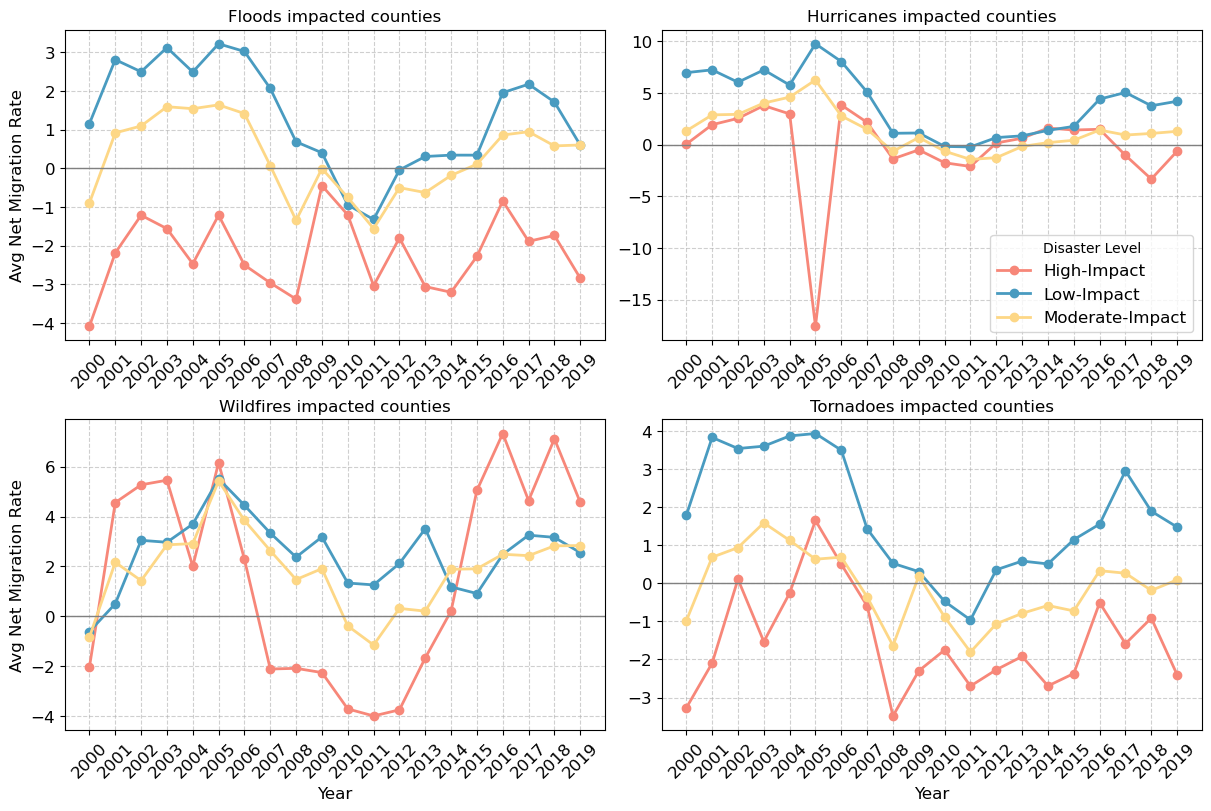

In [417]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.flatten()
years = list(range(2000, 2020))
fontsize = 12  # Slightly larger font for better readability

# Improved color palette for visual distinction
colors = ['#499BC0', '#FDD786', '#F78779']

# Plotting data for floods
axes[0].plot(years, yearly_flooding_high_mean.values, marker='o', linestyle='-', color=colors[2], label='High', linewidth=2)
axes[0].plot(years, yearly_flooding_low_mean.values, marker='o', linestyle='-', color=colors[0], label='Low', linewidth=2)
axes[0].plot(years, yearly_flooding_med_mean.values, marker='o', linestyle='-', color=colors[1], label='Medium', linewidth=2)
axes[0].set_title("Floods impacted counties", fontsize=fontsize)
# axes[0].set_xlabel("Year", fontsize=fontsize)
axes[0].set_ylabel("Avg Net Migration Rate", fontsize=fontsize)
axes[0].set_xticks(years)
axes[0].set_xticklabels(years, rotation=45, fontsize=fontsize)
axes[0].tick_params(axis='y', labelsize=fontsize)
# axes[0].legend(title="Disaster Level", fontsize=fontsize)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].axhline(0, color='gray', linewidth=1)

# Plotting data for hurricanes
axes[1].plot(years, yearly_hurricane_high_mean.values, marker='o', linestyle='-', color=colors[2], label='High-Impact', linewidth=2)
axes[1].plot(years, yearly_hurricane_low_mean.values, marker='o', linestyle='-', color=colors[0], label='Low-Impact', linewidth=2)
axes[1].plot(years, yearly_hurricane_med_mean.values, marker='o', linestyle='-', color=colors[1], label='Moderate-Impact', linewidth=2)
axes[1].set_title("Hurricanes impacted counties", fontsize=fontsize)
# axes[1].set_xlabel("Year", fontsize=fontsize)
# axes[1].set_ylabel("Avg Net Migration Rate", fontsize=fontsize)
axes[1].set_xticks(years)
axes[1].set_xticklabels(years, rotation=45, fontsize=fontsize)
axes[1].legend(title="Disaster Level",fontsize=fontsize,loc='lower right')
axes[1].tick_params(axis='y', labelsize=fontsize)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].axhline(0, color='gray', linewidth=1)

# Plotting data for wildfires
axes[2].plot(years, yearly_wildfire_high_mean.values, marker='o', linestyle='-', color=colors[2], label='High', linewidth=2)
axes[2].plot(years, yearly_wildfire_low_mean.values, marker='o', linestyle='-', color=colors[0], label='Low', linewidth=2)
axes[2].plot(years, yearly_wildfire_med_mean.values, marker='o', linestyle='-', color=colors[1], label='Medium', linewidth=2)
axes[2].set_title("Wildfires impacted counties", fontsize=fontsize)
axes[2].set_xlabel("Year", fontsize=fontsize)
axes[2].set_ylabel("Avg Net Migration Rate", fontsize=fontsize)
axes[2].set_xticks(years)
axes[2].set_xticklabels(years, rotation=45, fontsize=fontsize)
axes[2].tick_params(axis='y', labelsize=fontsize)
# axes[2].legend(title="Disaster Level", fontsize=fontsize)
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].axhline(0, color='gray', linewidth=1)

# Plotting data for tornadoes
axes[3].plot(years, yearly_tornado_high_mean.values, marker='o', linestyle='-', color=colors[2], label='High', linewidth=2)
axes[3].plot(years, yearly_tornado_low_mean.values, marker='o', linestyle='-', color=colors[0], label='Low', linewidth=2)
axes[3].plot(years, yearly_tornado_med_mean.values, marker='o', linestyle='-', color=colors[1], label='Medium', linewidth=2)
axes[3].set_title("Tornadoes impacted counties", fontsize=fontsize)
axes[3].set_xlabel("Year", fontsize=fontsize)
# axes[3].set_ylabel("Avg Net Migration Rate", fontsize=fontsize)
axes[3].set_xticks(years)
axes[3].set_xticklabels(years, rotation=45, fontsize=fontsize)
axes[3].tick_params(axis='y', labelsize=fontsize)
# axes[3].legend(title="Disaster Level", fontsize=fontsize)
axes[3].grid(True, linestyle='--', alpha=0.6)
axes[3].axhline(0, color='gray', linewidth=1)

# fig.savefig(r"F:\LongMig2025\results\maps\plot2\NMR_0402.png", dpi=300, bbox_inches="tight")


In [418]:
Floods = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Flooding"]
Floods = Floods.rename(columns={"frequency":"Flood_Frequency","PropertyDmgPerCapita(ADJ 2020)":"Flood_Loss","Fatalities":"Flood_Fatalities","Injuries":"Flood_Injuries"})
Hurricane = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Hurricane/Tropical Storm"]
Hurricane = Hurricane.rename(columns={"frequency":"Hurricane_Frequency","PropertyDmgPerCapita(ADJ 2020)":"Hurricane_Loss","Fatalities":"Hurricane_Fatalities","Injuries":"Hurricane_Injuries"})
Wildfire = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Wildfire"]
Wildfire = Wildfire.rename(columns={"frequency":"Wildfire_Frequency","PropertyDmgPerCapita(ADJ 2020)":"Wildfire_Loss","Fatalities":"Wildfire_Fatalities","Injuries":"Wildfire_Injuries"})
Tornado = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Tornado"]
Tornado = Tornado.rename(columns={"frequency":"Tornado_Frequency","PropertyDmgPerCapita(ADJ 2020)":"Tornado_Loss","Fatalities":"Tornado_Fatalities","Injuries":"Tornado_Injuries"})
# Heat = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Heat"]
# Heat = Heat.rename(columns={"frequency":"Heat_Frequency","PropertyDmgPerCapita(ADJ 2020)":"Heat_Loss","Fatalities":"Heat_Fatalities","Injuries":"Heat_Injuries"})
Floods["Flood_Occur"] = 1
Hurricane["Hurricane_Occur"] = 1
Wildfire["Wildfire_Occur"] = 1
Tornado["Tornado_Occur"] = 1
# Heat["Heat_Occur"] = 1
Floods = Floods[["County FIPS","Flood_Frequency","Flood_Loss","Flood_Occur","Flood_Fatalities","Flood_Injuries"]]
Hurricane = Hurricane[["County FIPS","Hurricane_Frequency","Hurricane_Loss","Hurricane_Occur","Hurricane_Fatalities","Hurricane_Injuries"]]
Wildfire = Wildfire[["County FIPS","Wildfire_Frequency","Wildfire_Loss","Wildfire_Occur","Wildfire_Fatalities","Wildfire_Injuries"]]
Tornado = Tornado[["County FIPS","Tornado_Frequency","Tornado_Loss","Tornado_Occur","Tornado_Fatalities","Tornado_Injuries"]]
# Heat = Heat[["County FIPS","Heat_Frequency","Heat_Loss","Heat_Occur","Heat_Fatalities","Heat_Injuries"]]

In [419]:
Disaster = pd.merge(Floods,Hurricane,on="County FIPS",how='outer')
Disaster = pd.merge(Disaster,Wildfire,on="County FIPS",how='outer')
Disaster = pd.merge(Disaster,Tornado,on="County FIPS",how='outer')
# Disaster = pd.merge(Disaster,Heat,on="County FIPS",how='outer')
Disaster = Disaster.fillna(0)

In [420]:
Disaster.head()

,County FIPS,Flood_Frequency,Flood_Loss,Flood_Occur,Flood_Fatalities,Flood_Injuries,Hurricane_Frequency,Hurricane_Loss,Hurricane_Occur,Hurricane_Fatalities,...,Wildfire_Frequency,Wildfire_Loss,Wildfire_Occur,Wildfire_Fatalities,Wildfire_Injuries,Tornado_Frequency,Tornado_Loss,Tornado_Occur,Tornado_Fatalities,Tornado_Injuries
0,01001,5.0,5.155596,1.0,0.0,0.0,2.0,3.644830,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,7.0,49.857632,1.0,3.0,57.0
1,01003,6.0,18.341990,1.0,2.0,1.0,4.0,18.590288,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,5.0,2.931754,1.0,0.0,7.0
2,01005,2.0,1.249390,1.0,0.0,0.0,2.0,1.754460,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,6.0,5.448765,1.0,0.0,4.0
3,01007,1.0,9.961340,1.0,0.0,0.0,2.0,8.162715,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,736.519440,1.0,1.0,10.0
4,01009,2.0,2.889540,1.0,0.0,0.0,1.0,1.463220,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,8.0,74.229791,1.0,0.0,40.0


### Compute Net Migration Rate (NMR)

In [421]:
correct_netmig_columns = []
for year in range(2001, 2021):
    column_name_x = f'RNETMIG{year}_x'
    column_name_y = f'RNETMIG{year}_y'
    column_name = f'RNETMIG{year}'
    if column_name in df_pep_0120.columns:
        correct_netmig_columns.append(column_name)
    elif column_name_x in df_pep_0120.columns:
        correct_netmig_columns.append(column_name_x)
    elif column_name_y in df_pep_0120.columns:
        correct_netmig_columns.append(column_name_y)

In [422]:
df_pep_0120["NetMigrationRateTotal"] = df_pep_0120[correct_netmig_columns].mean(axis=1)
df_pep_0120_used = df_pep_0120[['FIPS','STNAME_x', 'CTYNAME_x', 'NetMigrationRateTotal']]

In [423]:
# df_pep_0120.to_csv(data_path+"pep.csv")

In [424]:
df_NMR = pd.merge(df_pep_0120_used,county,on="FIPS",how="inner")
gdf_NMR = gpd.GeoDataFrame(df_NMR,geometry="geometry")

## NMR Map

<Figure size 1000x800 with 0 Axes>

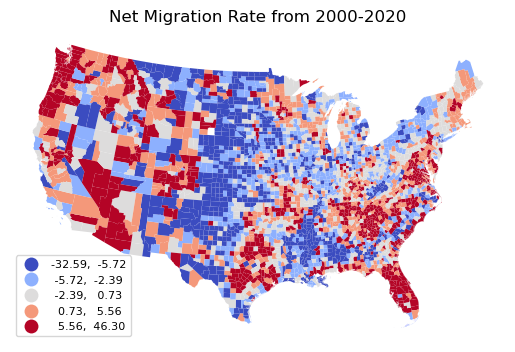

In [425]:
plt.figure(figsize=(10, 8))
gdf_NMR.plot(column="NetMigrationRateTotal",cmap="coolwarm",
             scheme="quantiles",
#              scheme='userdefined',classification_kwds={'bins':[-500,-100,-50,-25,-10,-0.1,0,0.1,10,25,50,100,500]},
             legend=True,legend_kwds={
        "fontsize": 8,  # Adjust font size for smaller text
        "loc": "lower left",  # Position the legend
    })
plt.title("Net Migration Rate from 2000-2020")
plt.axis('off')
plt.show()

## Disaster Map
### Map the frequency and loss

In [426]:
df_disaster = pd.merge(df_20_years_by_county,county,left_on="County FIPS",right_on="FIPS",how="inner")
gdf_disaster = gpd.GeoDataFrame(df_disaster,geometry="geometry")

C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\mapclassify\classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 4.
  self.bins = quantile(y, k=k)
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\mapclassify\classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 4.
  self.bins = quantile(y, k=k)


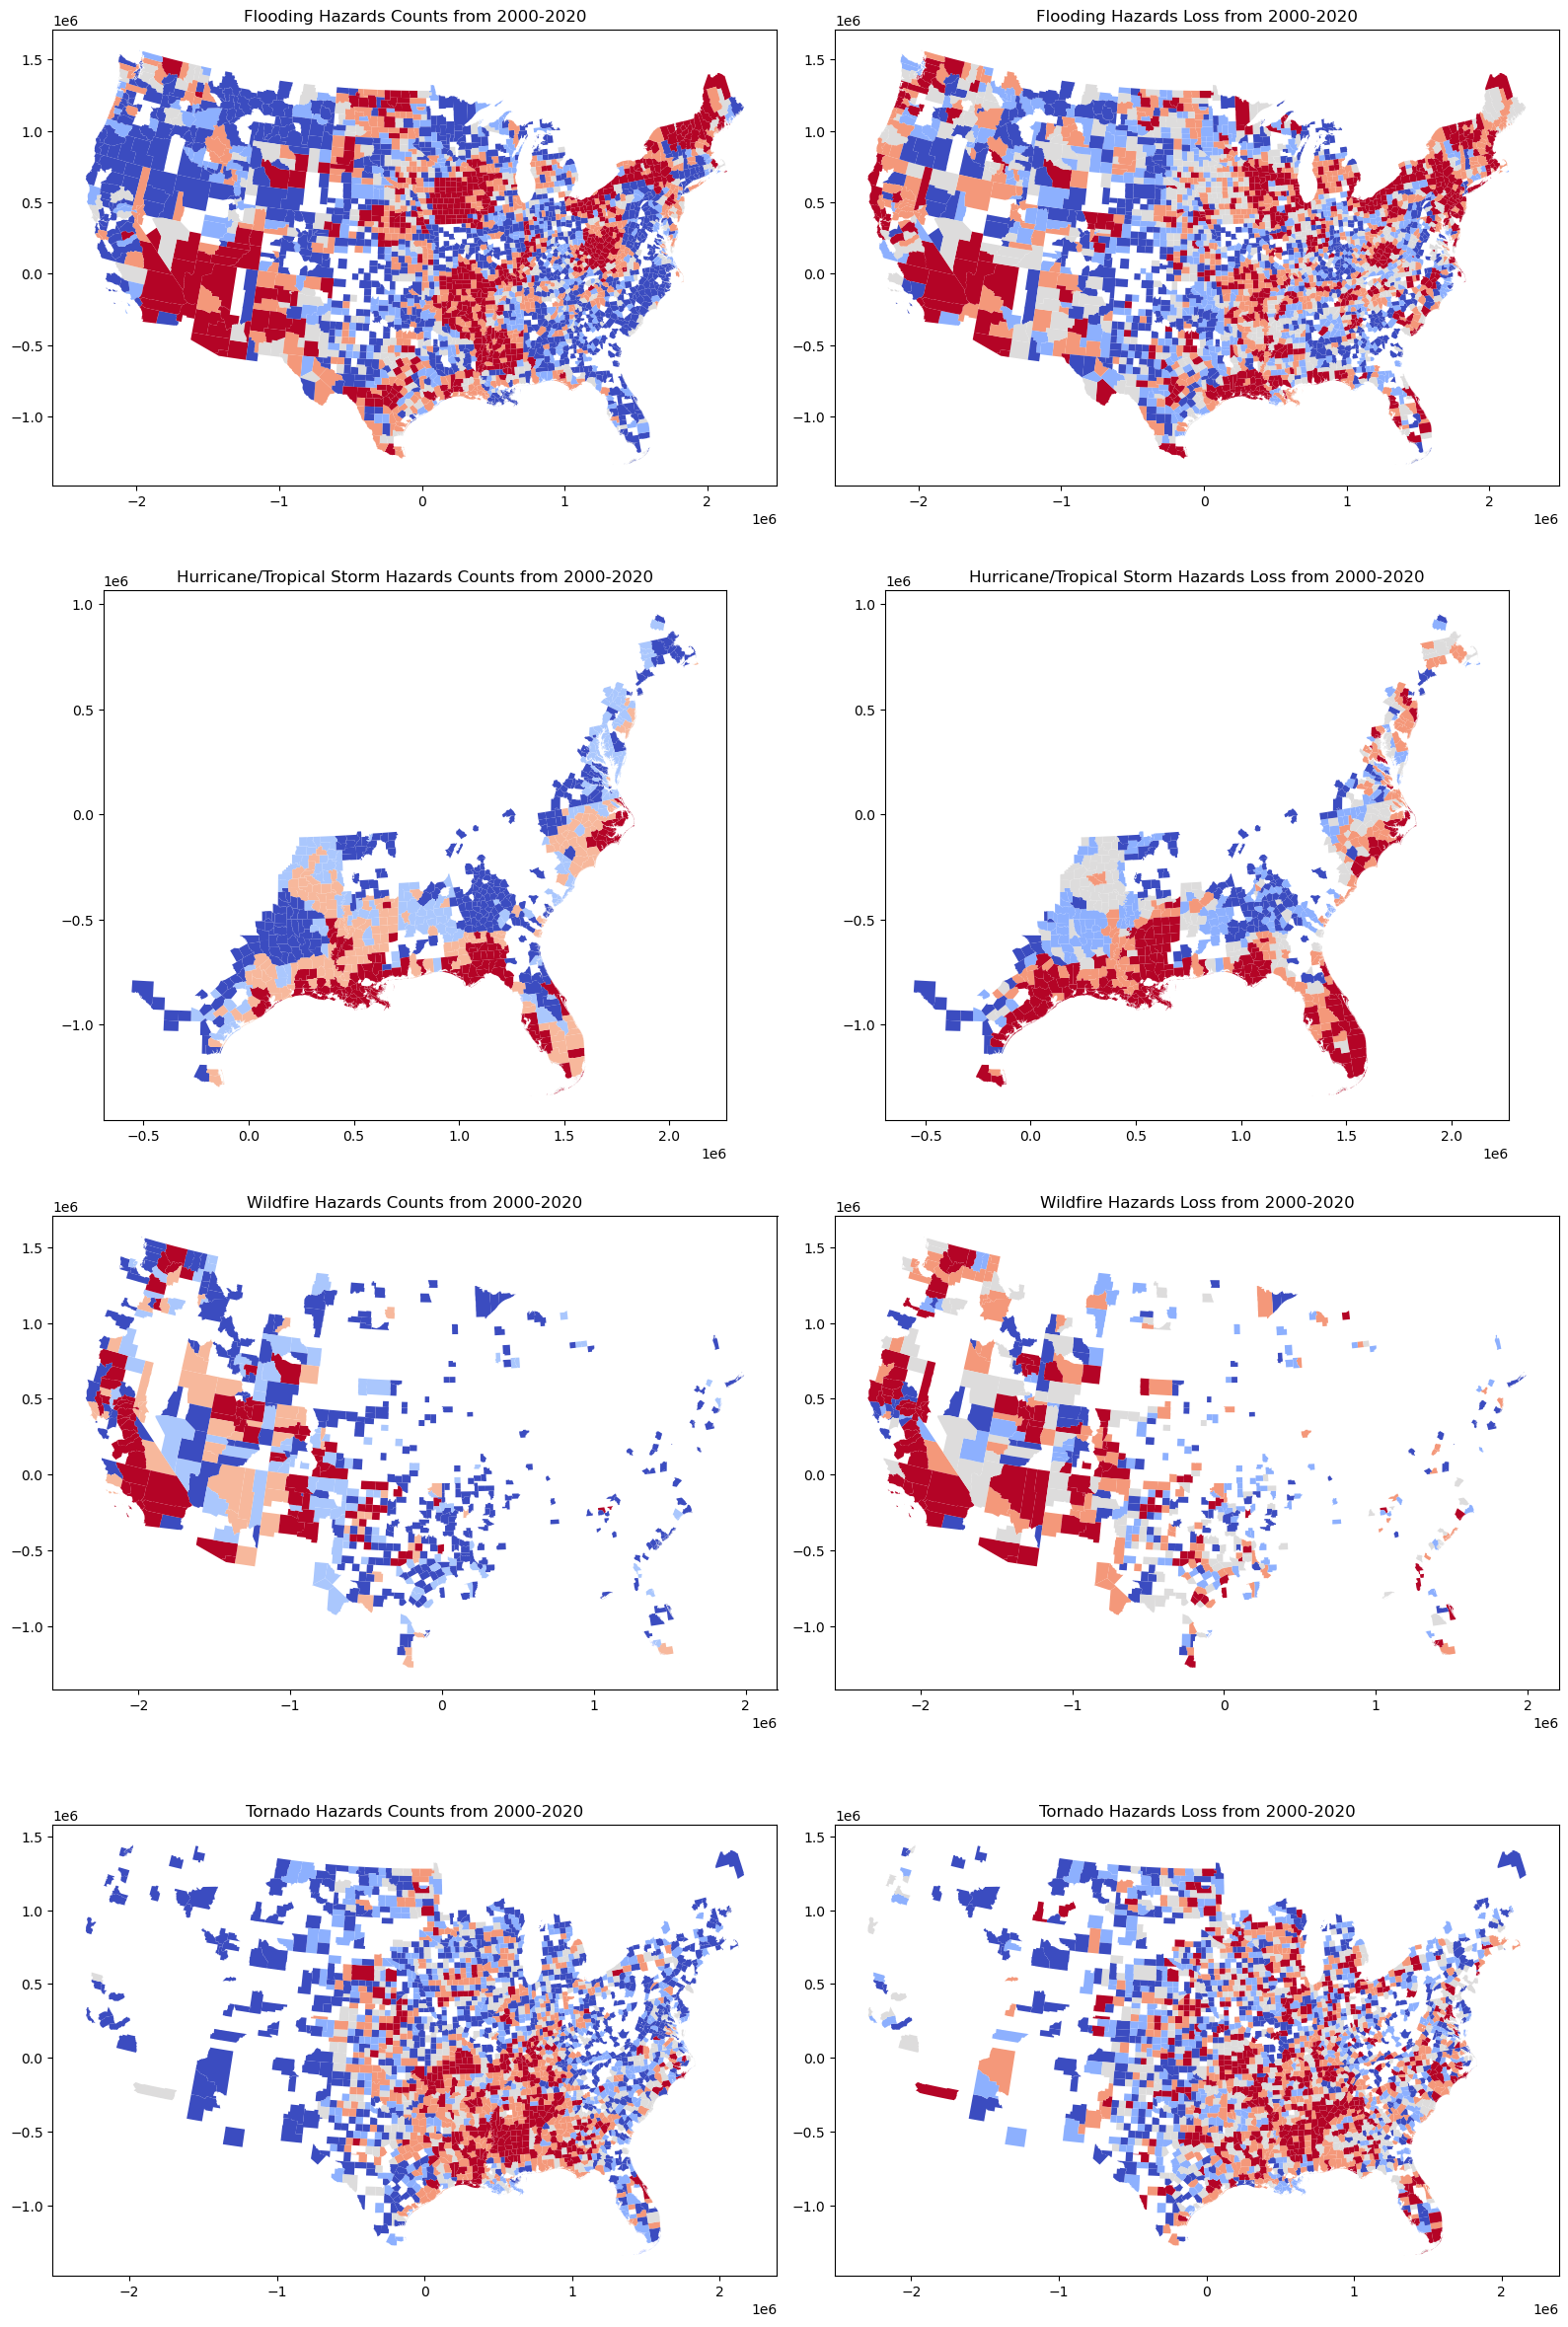

In [427]:
fig, axes = plt.subplots(4,2,figsize=(16,24))
list_disaster = ['Flooding','Hurricane/Tropical Storm','Wildfire','Tornado']
for i in range(4):
    use_df_disaster = gdf_disaster[gdf_disaster["Hazard"] == str(list_disaster[i])]
#     print(use_df_disaster.head())
    use_df_disaster.plot(column="frequency",cmap="coolwarm",scheme='quantiles',
#                          classification_kwds={'bins':[1,3,5,10,20,50]},
                         ax=axes[i,0])
    use_df_disaster.plot(column="PropertyDmg(ADJ 2020)",cmap="coolwarm",scheme="quantiles",
#                          ,legend=True,
                         ax=axes[i,1])
    axes[i,0].set_title(f"{list_disaster[i]} Hazards Counts from 2000-2020")
    axes[i,1].set_title(f"{list_disaster[i]} Hazards Loss from 2000-2020")
plt.tight_layout()
plt.show()

## XGBoost
### Combine each dataset

In [428]:
Regression_data = pd.DataFrame()
Regression_data = df_pep_0120
Regression_data = pd.merge(Regression_data,Disaster,left_on="FIPS",right_on="County FIPS",how="outer")
Regression_data = pd.merge(Regression_data,HAI,left_on="FIPS",right_on="FIPS",how="inner")
# Regression_data = pd.merge(Regression_data,Hurricane,left_on="FIPS",right_on="County FIPS",how="outer")
# Regression_data = pd.merge(Regression_data,Wildfire,left_on="FIPS",right_on="County FIPS",how="outer")
# Regression_data = pd.merge(Regression_data,Tornado,left_on="FIPS",right_on="County FIPS",how="outer")
# Regression_data = pd.merge(Regression_data,Heat,left_on="FIPS",right_on="County FIPS",how="outer")
Regression_data = pd.merge(Regression_data,SVI_10,on="FIPS",how="inner")
# Regression_data = pd.merge(Regression_data,NRI_CONUS,on="FIPS",how="inner")
# Regression_data = pd.merge(Regression_data,unemployment_rate_pivot,on="FIPS",how="inner")
Regression_data = pd.merge(Regression_data,PopDensity_CONUS_sel,on="FIPS",how="inner")
# Regression_data = pd.merge(Regression_data,conus_annual_prices,on="FIPS",how="inner")
Regression_data = pd.merge(Regression_data,MedianHouseValue,on="FIPS",how="inner")
# Regression_data = pd.merge(Regression_data,GDP_final_data,on="FIPS",how="inner")
Regression_data = pd.merge(Regression_data,T_sel,on="FIPS",how="inner")

In [429]:
Regression_data = Regression_data.fillna(0)

In [430]:
used_list = [
    "FIPS","NetMigrationRateTotal",#PEP
    "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss",
#     "Heat_Frequency","Heat_Loss",
    "E_P_POV","E_P_UNEMP","E_P_PCI","E_P_NOHSDIP","P_AGE65","P_AGE17","P_SNGPRNT",
    "P_MINORITY","E_P_LIMENG","E_P_MUNIT","E_P_MOBILE","E_P_CROWD","E_P_NOVEH","P_GROUPQ", #SVI
    "POPDENS10",#POP DENSITY
    "W_HT_HAI",#HAI
    "MedianHouseValue2000(adjusted)","ratiochange",#House Value
    'TJAN', 'TJULY' #Amenity
]
standard_list = [
    "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss",
#     "Heat_Frequency","Heat_Loss",
    "E_P_POV","E_P_UNEMP","E_P_PCI","E_P_NOHSDIP","P_AGE65","P_AGE17","P_SNGPRNT",
    "P_MINORITY","E_P_LIMENG","E_P_MUNIT","E_P_MOBILE","E_P_CROWD","E_P_NOVEH","P_GROUPQ", #SVI
    "POPDENS10",#POP DENSITY
    "W_HT_HAI",#HAI
    "MedianHouseValue2000(adjusted)","ratiochange",#House Value
    'TJAN', 'TJULY']

name_list = [
    "FIPS","NMR",
    "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss",
#     "Heat_Frequency","Heat_Loss",
    "%BelowPoverty","%Unemployed","PerCapitaIncome","%NoHighSchoolDiploma25+","%Age65+",
    "%Age18-","%Single-parent household","%Minority","%Age5+LessThanWellEnglish",
    "%Multi-Unit House","%MobileHome","%HousePop>Room","%NoVehicleHousehold","%GroupQuarters",
    "Pop Density",
    "HouseUnaffordability",
    "Median House Value in 2000","%Change of Median House Value",
    "Jan Temp","July Temp"
]

In [431]:
from sklearn.preprocessing import RobustScaler
Regression_data_used = Regression_data[used_list]
scaler = RobustScaler()
Regression_data_used[standard_list] = scaler.fit_transform(Regression_data_used[standard_list])
Regression_data_used.columns = name_list

C:\Users\xiang11\AppData\Local\Temp\ipykernel_24316\3681464180.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Regression_data_used[standard_list] = scaler.fit_transform(Regression_data_used[standard_list])


In [432]:
# Regression_data_used = Regression_data[used_list]
# Regression_data_used[zscore_list] = (Regression_data_used[zscore_list] - Regression_data_used[zscore_list].mean()) / Regression_data_used[zscore_list].std()
# Regression_data_used.columns = name_list

### XGBOOST with all factors in Hurricane, Flood, Wildfire, Tornado

## Test for the best parameters

In [433]:
X = Regression_data_used.drop(columns=['NMR', 'FIPS',"%Single-parent household","%Minority"])
y = Regression_data_used['NMR']

# # Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 500, 1000],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(xgb.XGBRegressor(objective="reg:squarederror"), param_grid, scoring="neg_mean_squared_error", cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 0.8}


## Summary Plot of XGBoost

Mean Squared Error: 21.575690672899785


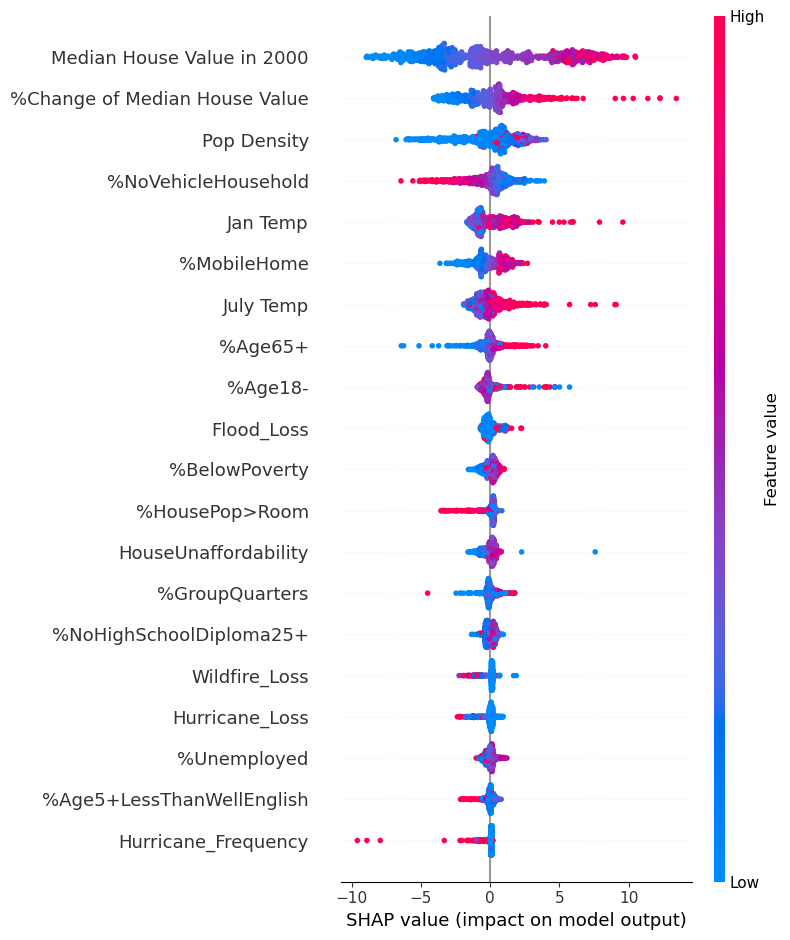

In [434]:
X = Regression_data_used.drop(columns=['NMR', 'FIPS',"%Single-parent household","%Minority"])
y = Regression_data_used['NMR']

# # Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# # Train an XGBoost regression model
model = xgb.XGBRegressor(objective='reg:squarederror',
                             n_estimators=1000,  
    learning_rate=0.05,
    max_depth=3,  
    subsample=0.8,  
    colsample_bytree=0.8,
    reg_lambda=1,  
    reg_alpha=0,  
    missing=0)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Explain the model with SHAP
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Summary plot of feature importance
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
# plt.savefig(r'F:\LongMig2025\results\maps\xgboost\summary.png', dpi=600, bbox_inches='tight')
fig.clf()

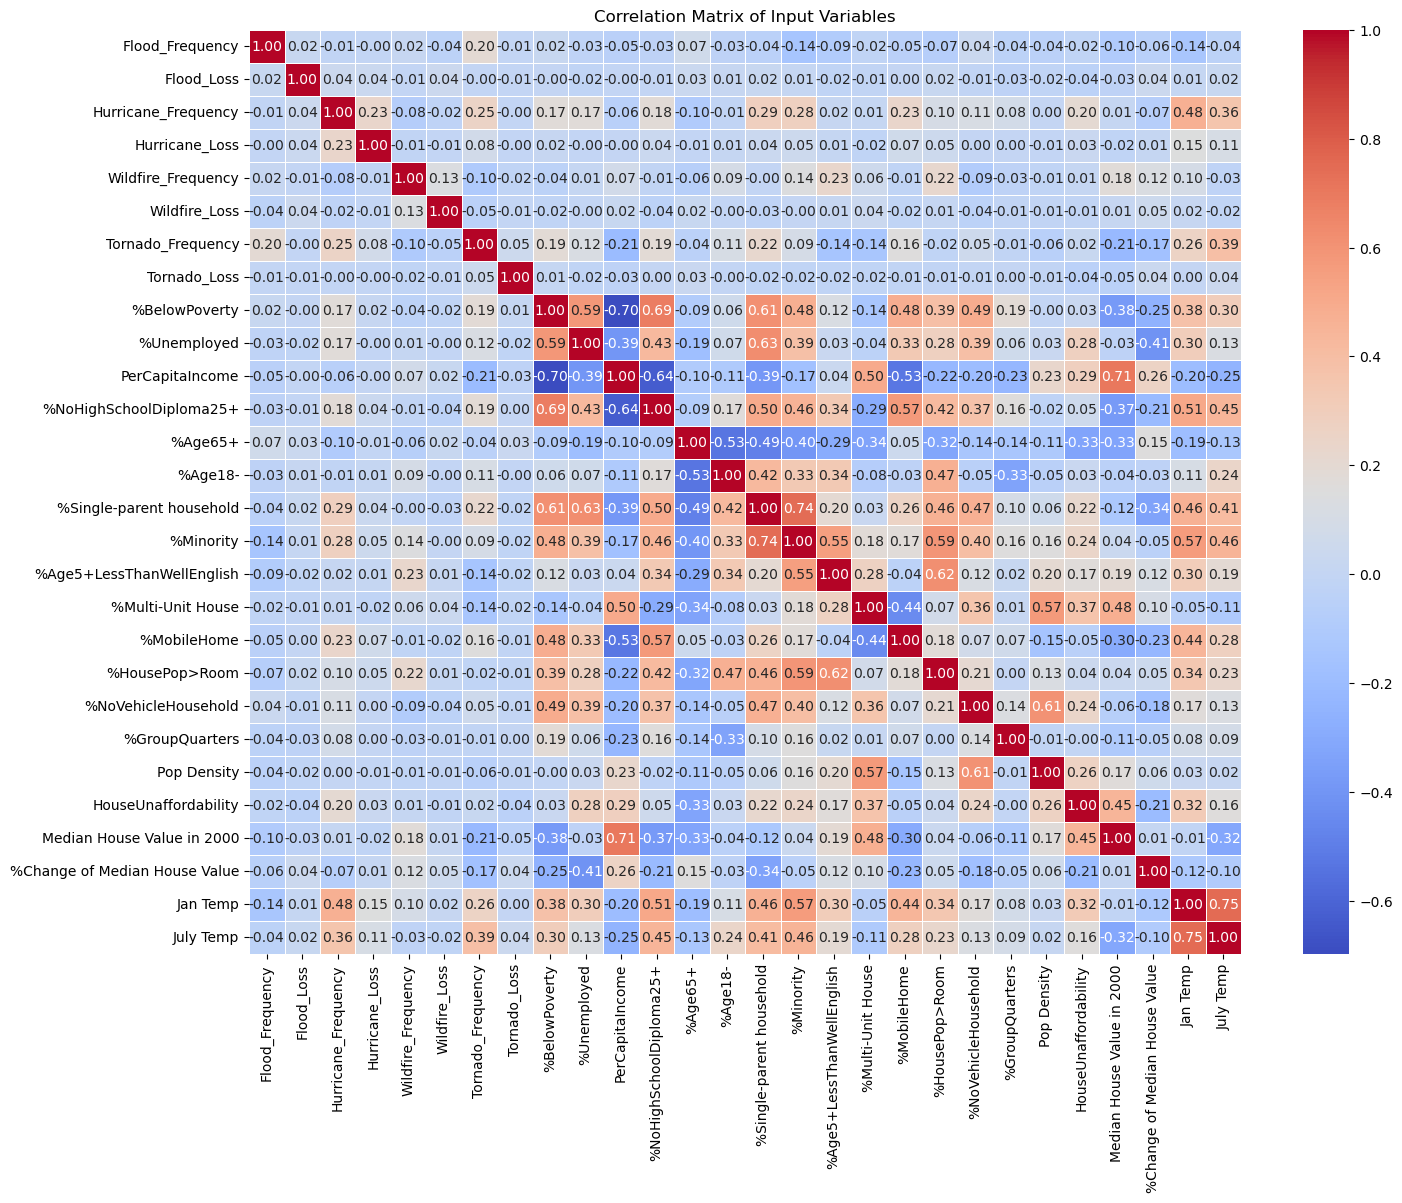

In [435]:
correlation_matrix = Regression_data_used.drop(columns=['NMR', 'FIPS']).corr()
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Input Variables")
plt.show()

## VIF to exclude some factors

In [436]:
# Exclude specified columns
excluded_columns = ["NMR", "FIPS"]
df_vif = Regression_data_used.drop(columns=excluded_columns, errors="ignore")

# Recalculate VIF for remaining variables
vif_data_filtered = pd.DataFrame()
vif_data_filtered["Feature"] = df_vif.columns
vif_data_filtered["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]
vif_data_filtered

,Feature,VIF
0,Flood_Frequency,1.206792
1,Flood_Loss,1.038901
2,Hurricane_Frequency,1.609147
3,Hurricane_Loss,1.080169
4,Wildfire_Frequency,1.263956
5,Wildfire_Loss,1.038387
6,Tornado_Frequency,1.402025
7,Tornado_Loss,1.012702
8,%BelowPoverty,4.224872
9,%Unemployed,2.503342


## VIF again

In [437]:
excluded_columns = ["NMR", "FIPS","%Single-parent household","%Minority"]
df_vif = Regression_data_used.drop(columns=excluded_columns, errors="ignore")

# Recalculate VIF for remaining variables
vif_data_filtered = pd.DataFrame()
vif_data_filtered["Feature"] = df_vif.columns
vif_data_filtered["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]

vif_data_filtered

,Feature,VIF
0,Flood_Frequency,1.191199
1,Flood_Loss,1.036008
2,Hurricane_Frequency,1.569651
3,Hurricane_Loss,1.078738
4,Wildfire_Frequency,1.254016
5,Wildfire_Loss,1.038156
6,Tornado_Frequency,1.400231
7,Tornado_Loss,1.012441
8,%BelowPoverty,3.969531
9,%Unemployed,2.113519


In [438]:
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MSE: 21.575690672899785
RMSE: 4.644964012013418
R2: 0.700756018430546


## F-value plot

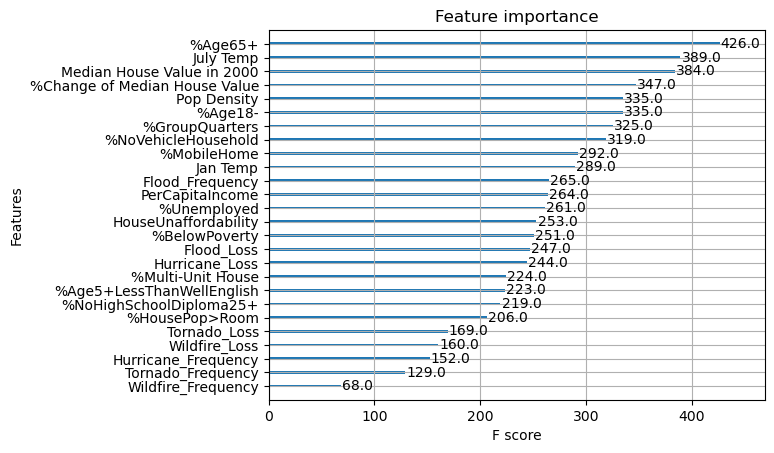

In [439]:
xgb.plot_importance(model)
plt.show()

## Cross Validation to test the stability

In [440]:
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("Cross-Validation R^2 Scores:", scores)
print("Mean R^2:", scores.mean())

Cross-Validation R^2 Scores: [0.51291054 0.43607088 0.61975293 0.64119614 0.57415099]
Mean R^2: 0.5568162975813225


## Dependence Plot of XGBoost

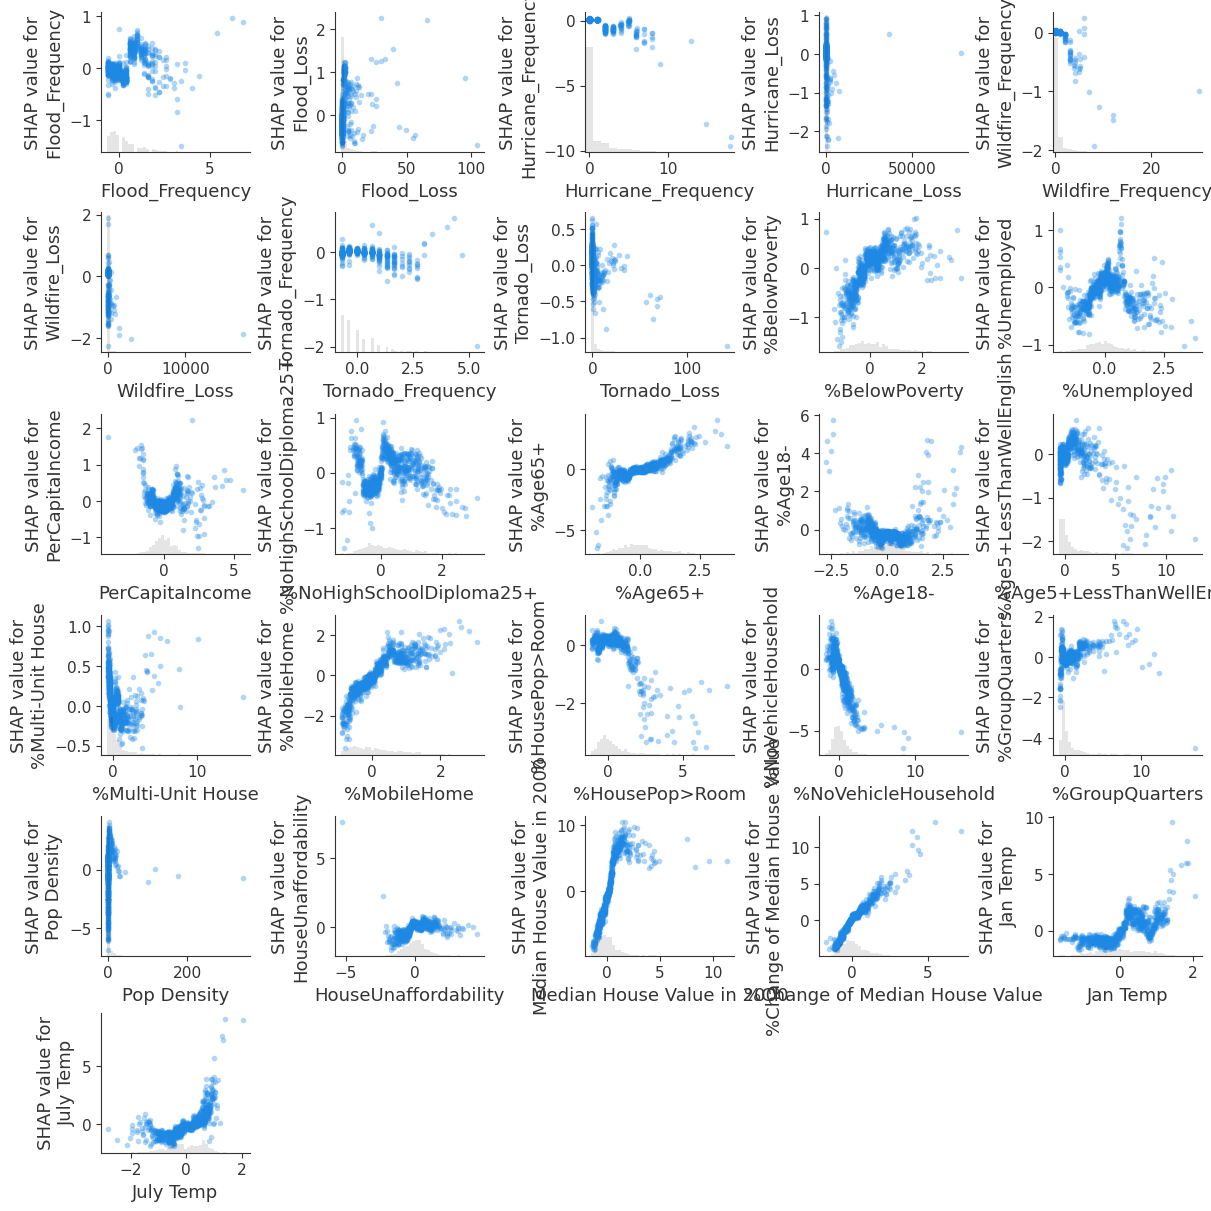

In [441]:
# Define all the features in your dataset
all_features = X_test.columns  # Replace with the features from your test set

# Set up the number of rows and columns for subplots
num_features = len(all_features)
cols = 5  # Number of columns in the subplot grid
rows = (num_features + cols - 1) // cols  # Calculate the number of rows needed

# Create the subplots
fig, axes = plt.subplots(rows, cols, figsize=(12, 12), constrained_layout=True)

# Flatten axes for easy iteration
axes = axes.flatten()

# Generate SHAP dependence plots for each feature
for i, feature in enumerate(all_features):
    shap.plots.scatter(shap_values[:, feature],ax=axes[i], show=False, alpha=0.35)
#     sns.regplot(x=X_test[feature], y=shap_values[:, feature], ax=axes[i], scatter_kws={'s': 10}, line_kws={'color': 'red'})
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
#     shap.dependence_plot(
#         feature, shap_values.values, X_test, ax=axes[i], show=False
#     )
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
    

# Turn off unused subplots if the number of features is less than total subplots
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")
plt.savefig(r'F:\LongMig2025\results\maps\xgboost\dependence.png', dpi=600, bbox_inches='tight')  # Specify the path and file name here

# Show the final figure
plt.show()


## Lasso test. The use of Lasso test is similar as VIF.

In [442]:
lasso = Lasso(alpha=0.01)
lasso.fit(X, y)

Lasso(alpha=0.01)

In [443]:
lasso_coef = pd.Series(lasso.coef_, index=X.columns)
lasso_coef = lasso_coef.sort_values(key=abs, ascending=False)
print(lasso_coef)

Jan Temp                         4.159929
%NoVehicleHousehold             -2.424781
%BelowPoverty                   -2.026979
%MobileHome                      1.999784
HouseUnaffordability             1.917399
%Change of Median House Value    1.900015
Median House Value in 2000       1.407301
%NoHighSchoolDiploma25+         -1.265115
%Unemployed                      1.222116
%Age65+                         -0.834145
PerCapitaIncome                 -0.802432
%Multi-Unit House                0.666073
July Temp                       -0.506652
%Age18-                         -0.501891
%Age5+LessThanWellEnglish       -0.440089
Hurricane_Frequency             -0.423644
%HousePop>Room                  -0.375424
Tornado_Frequency               -0.355375
%GroupQuarters                  -0.255969
Wildfire_Frequency              -0.165383
Pop Density                      0.034614
Flood_Loss                      -0.032506
Flood_Frequency                  0.031901
Tornado_Loss                    -0

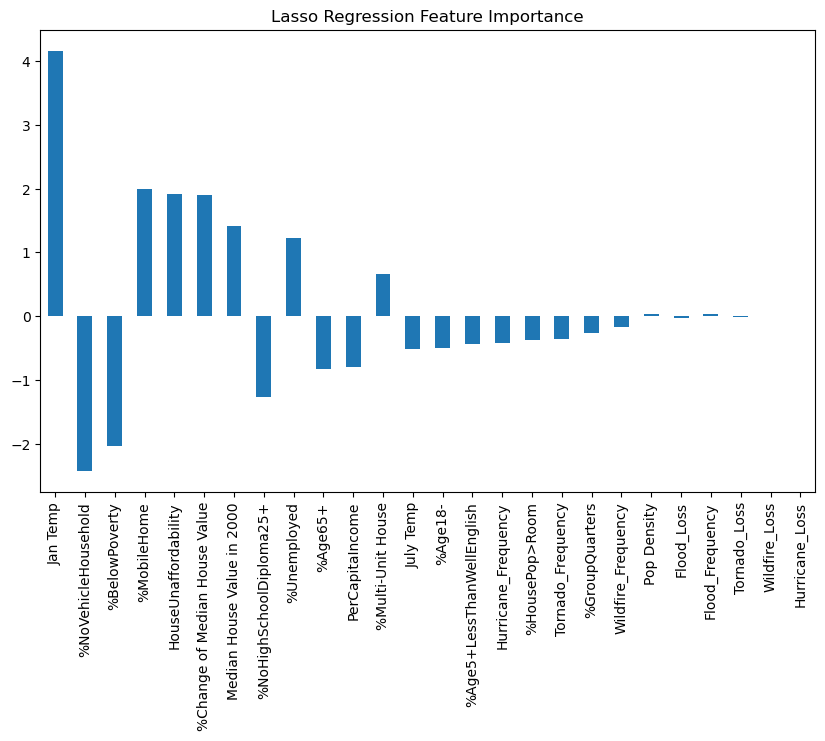

In [444]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
lasso_coef.plot(kind="bar")
plt.title("Lasso Regression Feature Importance")
plt.show()

## Summary Plot of XGBoost for Disaster Variables Only

 XGBoost R² Score: -0.0904
Mean Squared Error: 78.62134404539438


 95%|=================== | 737/776 [00:16<00:00]       

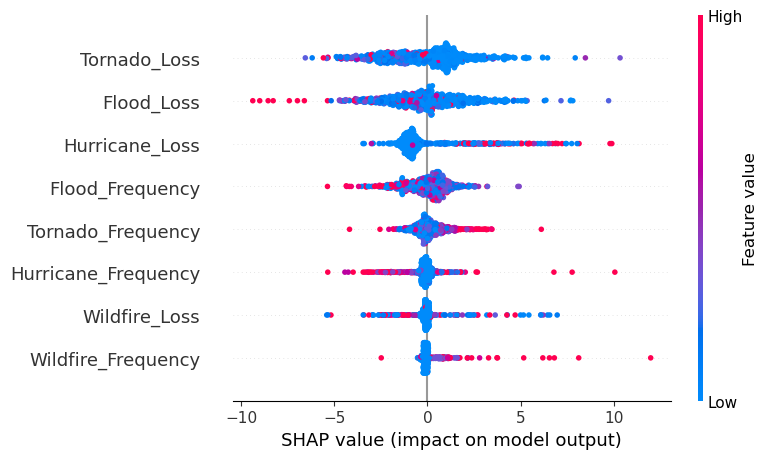

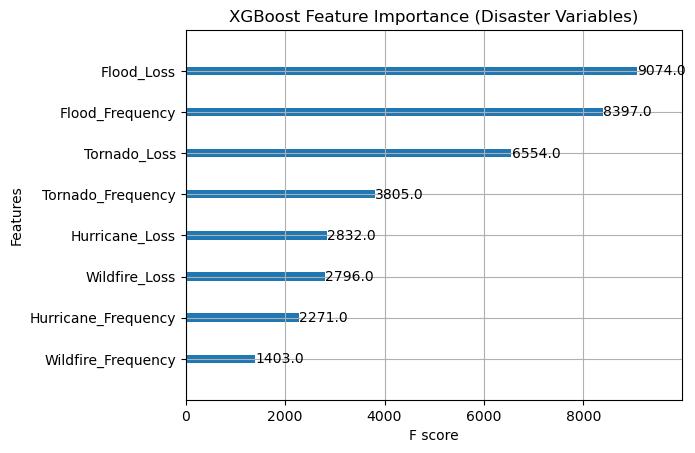

In [445]:
y = Regression_data_used['NMR']
disaster_vars = [col for col in Regression_data_used.columns if 'Flood' in col or 'Hurricane' in col or 'Tornado' in col or 'Wildfire' in col or 'Heat' in col]
X_disaster = Regression_data_used[disaster_vars]

# XGBoost
X_train, X_test, y_train, y_test = train_test_split(X_disaster, y, test_size=0.25, random_state=42)

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
xgb_r2 = r2_score(y_test, y_pred)
print(f" XGBoost R² Score: {xgb_r2:.4f}")

# Evaluate the model
y_pred = xgb_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Explain the model with SHAP
explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_test)

# Summary plot of feature importance
shap.summary_plot(shap_values, X_test)

xgb.plot_importance(xgb_model)
plt.title("XGBoost Feature Importance (Disaster Variables)")
plt.show()

In [446]:
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MSE: 78.62134404539438
RMSE: 8.866867769702804
R2: -0.09043851180332374


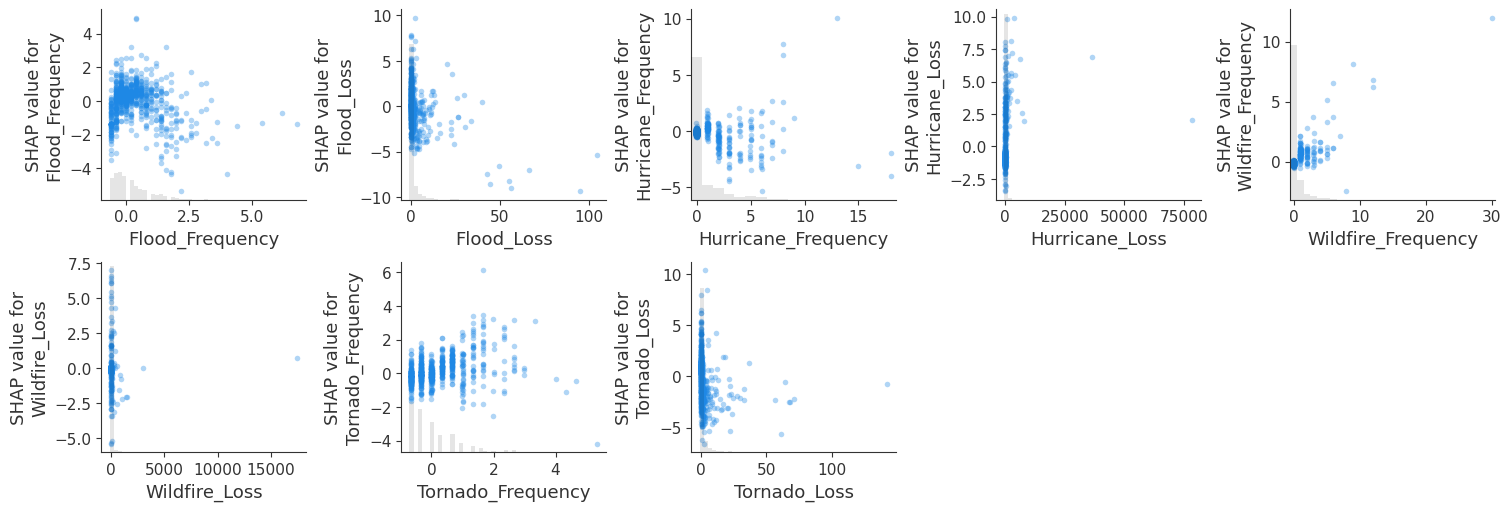

In [447]:
# Define all the features in your dataset
all_features = X_test.columns  # Replace with the features from your test set

# Set up the number of rows and columns for subplots
num_features = len(all_features)
cols = 5  # Number of columns in the subplot grid
rows = (num_features + cols - 1) // cols  # Calculate the number of rows needed

# Create the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 5), constrained_layout=True)

# Flatten axes for easy iteration
axes = axes.flatten()

# Generate SHAP dependence plots for each feature
for i, feature in enumerate(all_features):
    shap.plots.scatter(shap_values[:, feature],ax=axes[i], show=False, alpha=0.35)
#     shap.dependence_plot(
#         feature, shap_values.values, X_test, ax=axes[i], show=False
#     )
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
    

# Turn off unused subplots if the number of features is less than total subplots
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")

# Show the final figure
plt.show()


## Hierarchical Regression
## Hierarchical Regression of All Variables

In [467]:
Regression_data_used_ols = Regression_data_used.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (All Variables)")
print(model_ols.summary())

r_squared = model_ols.rsquared
y_pred = model_ols.predict(X_ols)
rmse = np.sqrt(mean_squared_error(y, y_pred))
me = np.mean(y - y_pred)
print("R-squared:", r_squared)
print("RMSE:", rmse)
print("ME:", me)

# 2 VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nVIF")
print(vif_data)

# OLS (Removed)
high_vif_features = vif_data[vif_data["VIF"] > 5]["Feature"].tolist()
X_filtered = X.drop(columns=high_vif_features)  
X_filtered = sm.add_constant(X_filtered)  

model_ols_filtered = sm.OLS(y, X_filtered).fit()
print("\nOLS（No Collinear Variables）：")
print(model_ols_filtered.summary())
r_squared_1 = model_ols_filtered.rsquared
y_pred_1 = model_ols_filtered.predict(X_filtered)
rmse_1 = np.sqrt(mean_squared_error(y, y_pred_1))
me_1 = np.mean(y - y_pred_1)
print("R-squared:", r_squared_1)
print("RMSE:", rmse_1)
print("ME:", me_1)

OLS (All Variables)
                            OLS Regression Results                            
Dep. Variable:                    NMR   R-squared:                       0.454
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     91.13
Date:                Wed, 30 Apr 2025   Prob (F-statistic):               0.00
Time:                        23:15:08   Log-Likelihood:                -10016.
No. Observations:                3102   AIC:                         2.009e+04
Df Residuals:                    3073   BIC:                         2.027e+04
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

In [449]:
X_ols = sm.add_constant(X_disaster)
model_ols = sm.OLS(y, X_ols).fit()
print("OLS Regression（Only Disaster Variables）：")
print(model_ols.summary())

OLS Regression（Only Disaster Variables）：
                            OLS Regression Results                            
Dep. Variable:                    NMR   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     11.10
Date:                Wed, 30 Apr 2025   Prob (F-statistic):           1.39e-15
Time:                        23:00:06   Log-Likelihood:                -10910.
No. Observations:                3102   AIC:                         2.184e+04
Df Residuals:                    3093   BIC:                         2.189e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

In [452]:
used_list1 = [
    "FIPS","NetMigrationRateTotal",#PEP
    "Flood_Frequency","Flood_Loss","Flood_Fatalities","Flood_Injuries",
    "Hurricane_Frequency","Hurricane_Loss","Hurricane_Fatalities","Hurricane_Injuries",
    "Wildfire_Frequency","Wildfire_Loss","Wildfire_Fatalities","Wildfire_Injuries",
    "Tornado_Frequency","Tornado_Loss","Tornado_Fatalities","Tornado_Injuries",
#     "Heat_Frequency","Heat_Loss","Heat_Fatalities","Heat_Injuries",
    "E_P_POV","E_P_UNEMP","E_P_PCI","E_P_NOHSDIP","P_AGE65","P_AGE17",
    "E_P_LIMENG","E_P_MUNIT","E_P_MOBILE","E_P_CROWD","E_P_NOVEH","P_GROUPQ", #SVI
    "POPDENS10",#POP DENSITY
    "W_HT_HAI",#HAI
    "MedianHouseValue2000(adjusted)","ratiochange",#House Price
    'TJAN', 'TJULY' #Amenity
]
standard_list1 = [
    "Flood_Frequency","Flood_Loss","Flood_Fatalities","Flood_Injuries",
    "Hurricane_Frequency","Hurricane_Loss","Hurricane_Fatalities","Hurricane_Injuries",
    "Wildfire_Frequency","Wildfire_Loss","Wildfire_Fatalities","Wildfire_Injuries",
    "Tornado_Frequency","Tornado_Loss","Tornado_Fatalities","Tornado_Injuries",
#     "Heat_Frequency","Heat_Loss","Heat_Fatalities","Heat_Injuries",
    "E_P_POV","E_P_UNEMP","E_P_PCI","E_P_NOHSDIP","P_AGE65","P_AGE17","E_P_LIMENG","E_P_MUNIT","E_P_MOBILE","E_P_CROWD","E_P_NOVEH","P_GROUPQ", #SVI
    "POPDENS10",#POP DENSITY
    "W_HT_HAI",#HAI
    "MedianHouseValue2000(adjusted)","ratiochange",#House Price
    'TJAN', 'TJULY']

name_list1 = [
    "FIPS","NMR",
    "Flood_Frequency","Flood_Loss","Flood_Fatalities","Flood_Injuries",
    "Hurricane_Frequency","Hurricane_Loss","Hurricane_Fatalities","Hurricane_Injuries",
    "Wildfire_Frequency","Wildfire_Loss","Wildfire_Fatalities","Wildfire_Injuries",
    "Tornado_Frequency","Tornado_Loss","Tornado_Fatalities","Tornado_Injuries",
#     "Heat_Frequency","Heat_Loss","Heat_Fatalities","Heat_Injuries",
    "%BelowPoverty","%Unemployed","PerCapitaIncome","%NoHighSchoolDiploma25+","%Age65+",
    "%Age18-","%Age5+LessThanWellEnglish",
    "%Multi-Unit House","%MobileHome","%HousePop>Room","%NoVehicleHousehold","%GroupQuarters",
    "Pop Density",
    "Affordability",
    "Median House Value in 2000","%Change of Median House Value",
    "Jan Temp","July Temp"
]

In [453]:
Regression_data_used1 = Regression_data[used_list1]
scaler = StandardScaler()
Regression_data_used1[standard_list1] = scaler.fit_transform(Regression_data_used1[standard_list1])
Regression_data_used1.columns = name_list1

C:\Users\xiang11\AppData\Local\Temp\ipykernel_24316\2935102092.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Regression_data_used1[standard_list1] = scaler.fit_transform(Regression_data_used1[standard_list1])


In [454]:
Regression_data_used1.head()

,FIPS,NMR,Flood_Frequency,Flood_Loss,Flood_Fatalities,Flood_Injuries,Hurricane_Frequency,Hurricane_Loss,Hurricane_Fatalities,Hurricane_Injuries,...,%MobileHome,%HousePop>Room,%NoVehicleHousehold,%GroupQuarters,Pop Density,Affordability,Median House Value in 2000,%Change of Median House Value,Jan Temp,July Temp
0,01001,5.813354,0.166456,-0.199688,-0.304688,-0.115321,0.713106,-0.087453,-0.035352,-0.032062,...,0.879834,-0.469726,-0.231392,-0.601378,-0.094700,0.762144,0.249803,-0.449965,1.171206,0.950576
1,01003,22.393108,0.403639,-0.164562,0.920366,0.142778,1.798512,-0.079435,-0.035352,-0.032062,...,0.106688,-0.083872,-0.798332,-0.497160,-0.081498,0.449899,0.874889,-0.388730,1.547502,1.093171
2,01005,-7.284080,-0.545092,-0.210093,-0.304688,-0.115321,0.713106,-0.088468,-0.035352,-0.032062,...,1.806597,-0.127722,1.244821,1.956696,-0.129904,0.470643,-0.341412,-1.449823,1.288792,0.960546
3,01007,1.336304,-0.782275,-0.186886,-0.304688,-0.115321,0.713106,-0.085029,-0.035352,-0.032062,...,1.808380,-0.531823,-0.219218,1.501927,-0.126546,-0.387252,-0.206029,-1.378611,1.032805,0.949406
4,01009,5.568893,-0.545092,-0.205724,-0.304688,-0.115321,0.170404,-0.088624,-0.035352,-0.032062,...,0.992241,0.346162,-0.767593,-0.596641,-0.096379,0.305980,0.069287,-0.772276,0.775228,0.606038


In [455]:
flooding_list
flooding_low_list
flooding_medhigh_list = list(set(flooding_list)-set(flooding_low_list))

hurricane_list
hurricane_low_list
hurricane_medhigh_list = list(set(hurricane_list)-set(hurricane_low_list))

wildfire_list
wildfire_low_list
wildfire_medhigh_list = list(set(wildfire_list)-set(wildfire_low_list))

tornado_list
tornado_low_list
tornado_medhigh_list = list(set(tornado_list)-set(tornado_low_list))


## Hierarchical Regression of Flood
## Six summary tables are:
### 1) Total counties with socio-economic variables only
### 2) Total counties with all variables (disaster+socio-economic)
### 3) Low impacted counties with socio-economic variables only
### 4) Low impacted counties with all variables (disaster+socio-economic)
### 5) Moderate and high impacted counties with socio-economic variables only
### 6) Moderate and high impacted counties with all variables (disaster+socio-economic)

In [456]:
disaster_vars = [col for col in Regression_data_used1.columns if 'Hurricane' in col or 'Tornado' in col or 'Wildfire' in col or 'Heat' in col]
disaster_vars1 = [col for col in Regression_data_used1.columns if 'Flood' in col or 'Hurricane' in col or 'Tornado' in col or 'Wildfire' in col or 'Heat' in col]

total_flood = Regression_data_used1[Regression_data_used1["FIPS"].isin(flooding_list)]

Regression_data_used_ols = total_flood.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco)")
print(model_ols.summary())

Regression_data_used_ols = total_flood.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables)")
print(model_ols.summary())

low_flood = Regression_data_used1[Regression_data_used1["FIPS"].isin(flooding_low_list)]

Regression_data_used_ols = low_flood.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco LOW)")
print(model_ols.summary())

Regression_data_used_ols = low_flood.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables LOW)")
print(model_ols.summary())


high_flood = Regression_data_used1[Regression_data_used1["FIPS"].isin(flooding_medhigh_list)]

Regression_data_used_ols = high_flood.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco HIGH)")
print(model_ols.summary())

Regression_data_used_ols = high_flood.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables HIGH)")
print(model_ols.summary())

OLS (Total Socio-eco)
                            OLS Regression Results                            
Dep. Variable:                    NMR   R-squared:                       0.392
Model:                            OLS   Adj. R-squared:                  0.388
Method:                 Least Squares   F-statistic:                     98.56
Date:                Wed, 30 Apr 2025   Prob (F-statistic):          9.09e-281
Time:                        23:02:45   Log-Likelihood:                -9042.5
No. Observations:                2771   AIC:                         1.812e+04
Df Residuals:                    2752   BIC:                         1.824e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------

## Hierarchical Regression of Hurricane

In [457]:
disaster_vars = [col for col in Regression_data_used1.columns if 'Flood' in col or 'Tornado' in col or 'Wildfire' in col or 'Heat' in col]
disaster_vars1 = [col for col in Regression_data_used1.columns if 'Flood' in col or 'Hurricane' in col or 'Tornado' in col or 'Wildfire' in col or 'Heat' in col]

total_hurricane = Regression_data_used1[Regression_data_used1["FIPS"].isin(hurricane_list)]

Regression_data_used_ols = total_hurricane.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco)")
print(model_ols.summary())

Regression_data_used_ols = total_hurricane.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables)")
print(model_ols.summary())

low_hurricane = Regression_data_used1[Regression_data_used1["FIPS"].isin(hurricane_low_list)]

Regression_data_used_ols = low_hurricane.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco LOW)")
print(model_ols.summary())

Regression_data_used_ols = low_hurricane.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables LOW)")
print(model_ols.summary())


high_hurricane = Regression_data_used1[Regression_data_used1["FIPS"].isin(hurricane_medhigh_list)]

Regression_data_used_ols = high_hurricane.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco HIGH)")
print(model_ols.summary())

Regression_data_used_ols = high_hurricane.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables HIGH)")
print(model_ols.summary())

OLS (Total Socio-eco)
                            OLS Regression Results                            
Dep. Variable:                    NMR   R-squared:                       0.528
Model:                            OLS   Adj. R-squared:                  0.516
Method:                 Least Squares   F-statistic:                     43.47
Date:                Wed, 30 Apr 2025   Prob (F-statistic):          3.37e-101
Time:                        23:02:46   Log-Likelihood:                -2410.8
No. Observations:                 719   AIC:                             4860.
Df Residuals:                     700   BIC:                             4946.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------

## Hierarchical Regression of Wildfire

In [458]:
disaster_vars = [col for col in Regression_data_used1.columns if 'Hurricane' in col or 'Tornado' in col or 'Flood' in col or 'Heat' in col]
disaster_vars1 = [col for col in Regression_data_used1.columns if 'Flood' in col or 'Hurricane' in col or 'Tornado' in col or 'Wildfire' in col or 'Heat' in col]

total_wildfire = Regression_data_used1[Regression_data_used1["FIPS"].isin(wildfire_list)]

Regression_data_used_ols = total_wildfire.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco)")
print(model_ols.summary())

Regression_data_used_ols = total_wildfire.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables)")
print(model_ols.summary())

low_wildfire = Regression_data_used1[Regression_data_used1["FIPS"].isin(wildfire_low_list)]

Regression_data_used_ols = low_wildfire.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco LOW)")
print(model_ols.summary())

Regression_data_used_ols = low_wildfire.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables LOW)")
print(model_ols.summary())


high_wildfire = Regression_data_used1[Regression_data_used1["FIPS"].isin(wildfire_medhigh_list)]

Regression_data_used_ols = high_wildfire.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco HIGH)")
print(model_ols.summary())

Regression_data_used_ols = high_wildfire.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables HIGH)")
print(model_ols.summary())

OLS (Total Socio-eco)
                            OLS Regression Results                            
Dep. Variable:                    NMR   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.450
Method:                 Least Squares   F-statistic:                     25.74
Date:                Wed, 30 Apr 2025   Prob (F-statistic):           9.98e-61
Time:                        23:02:46   Log-Likelihood:                -1832.4
No. Observations:                 546   AIC:                             3703.
Df Residuals:                     527   BIC:                             3785.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------

## Hierarchical Regression of Tornado

In [459]:
disaster_vars = [col for col in Regression_data_used1.columns if 'Hurricane' in col or 'Flood' in col or 'Wildfire' in col or 'Heat' in col]
disaster_vars1 = [col for col in Regression_data_used1.columns if 'Flood' in col or 'Hurricane' in col or 'Tornado' in col or 'Wildfire' in col or 'Heat' in col]

total_tornado = Regression_data_used1[Regression_data_used1["FIPS"].isin(tornado_list)]

Regression_data_used_ols = total_tornado.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco)")
print(model_ols.summary())

Regression_data_used_ols = total_tornado.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables)")
print(model_ols.summary())

low_tornado = Regression_data_used1[Regression_data_used1["FIPS"].isin(tornado_low_list)]

Regression_data_used_ols = low_tornado.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco LOW)")
print(model_ols.summary())

Regression_data_used_ols = low_tornado.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables LOW)")
print(model_ols.summary())


high_tornado = Regression_data_used1[Regression_data_used1["FIPS"].isin(tornado_medhigh_list)]

Regression_data_used_ols = high_tornado.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco HIGH)")
print(model_ols.summary())

Regression_data_used_ols = high_tornado.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables HIGH)")
print(model_ols.summary())

OLS (Total Socio-eco)
                            OLS Regression Results                            
Dep. Variable:                    NMR   R-squared:                       0.480
Model:                            OLS   Adj. R-squared:                  0.475
Method:                 Least Squares   F-statistic:                     115.0
Date:                Wed, 30 Apr 2025   Prob (F-statistic):          5.65e-302
Time:                        23:02:47   Log-Likelihood:                -7300.5
No. Observations:                2265   AIC:                         1.464e+04
Df Residuals:                    2246   BIC:                         1.475e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------